   #  MP307 Practical 2 Queueing Theory II

**Name:** Cian Mac Liatháin

**ID:** 11476078

## Python functions

The Python functions contained in this notebook are:

1. `Nearneigh(pup,pdown,r)`. This generates the transition matrix `P` for a simple nearest neighbour model with maximum size `r` and probability `pup` of one step up transition and  `pdown` for one step down transition. The output is the transition matrix.

2. `Equilibrium(P)`. This computes the equilibrium probabilities for a given transition matrix `P`. If the system is not ergodic then an error message appears. The output is an array.

3. `Queue(P,n0,nit)`. This simulates a queue for a given transition matrix `P` with initial queue size `n0` for `nit`  iterations. The output is a list of simulated queue data.

4. `Qplot(qdata,pi)`. This generates an animation of the queue for any input data list `qdata`. The second argument is optional and consists of the equilibrium probabilities `pi` (if they exist and have been calculated via `Equilibrium(P)` above or otherwise). The output is a Python animation where 50 plots are shown for the normalised frequency of events which can be compared to a plot of the equilibrium probabilities `pi` if provided. 

In [1]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
import random as ran

In [2]:
def Nearneigh (pup, pdown, r):
    # This generates the transition matrix P for a nearest neighbour model with 
    # maximum size r and probability pup of one step up transition and pdown 
    # for one step down transition. 
    # The output is the transition matrix P.
    P = np.zeros((r + 1, r + 1))
    P[0, 0] = 1 - pup
    P[0, 1] = pup
    P[r , r ] = 1 - pdown
    P[r , r - 1] = pdown
    for i in range(1, r):
        P[i, i - 1] = pdown
        P[i , i] = 1 - pdown - pup
        P[i , i + 1] = pup
    return(P)


## Example. 
Find the transition matrix for a queue of maximum size 5 with prob customer arrival=0.2 and prob customer servicing=0.3

In [3]:
P=Nearneigh(0.2,0.3,5)
print(P)

[[0.8 0.2 0.  0.  0.  0. ]
 [0.3 0.5 0.2 0.  0.  0. ]
 [0.  0.3 0.5 0.2 0.  0. ]
 [0.  0.  0.3 0.5 0.2 0. ]
 [0.  0.  0.  0.3 0.5 0.2]
 [0.  0.  0.  0.  0.3 0.7]]


In [4]:
def Equilibrium (P):
    # This computes the equilibrium probabilities pi for a given transition matrix P. 
    # If the system is not ergodic then an error message appears. 
    # The output is an array.
    degenflag = 0
    n = len(P)
    pi = np.zeros((n))
    for i in range(n):
        if float(sum(P[i,:]))!= 1.0:
            print("ERROR: row",i,"of P does not sum to 1 !")
    eigenvals, eigenvects=np.linalg.eig(P.transpose()) # eigendata for P transpose
    for k in range(n):
        if abs(eigenvals[k]-1)< 1.0e-14:
            degenflag = degenflag + 1
            k1=k # label for eigenvalue 1.
    if 1 < degenflag:
        print("ERROR: P is not Ergodic")
    else:
        v=eigenvects[:,k1]
        pi=v/sum(v)
    return(pi.real)

In [5]:
pi=Equilibrium(P)
print(pi)

[0.36541353 0.24360902 0.16240602 0.10827068 0.07218045 0.0481203 ]


In [6]:
def Queue (P, n0, nit):
# This simulates a queue for a given transition matrix P with initial queue size n0 for nit iterations. 
# The output is a list of simulated queue data.
    nP = len(P)
# pp is a relabelled transition matrix with row elements in decreasing order.
# This is used to speed up the simulation process
# The relabelling is stored in the matrix loc.
    pp = np.zeros((nP,nP))
    for i in range(nP):
        for j in range(nP):
            pp[i, j] = P[i, j]
    loc = np.array([list(range(nP))]*nP)
    for i in range(nP):
        for j in range(nP-1):
            maxpp = pp[i, j]
            kmax = j
            for k in range(j, nP):
                if maxpp < pp[i, k]:
                    maxpp = pp[i, k]
                    kmax = k
                    pp[i, j], pp[i, k] = pp[i, k], pp[i, j]
                    loc[i, j], loc[i, k] = loc[i, k], loc[i, j]
    n = n0
    qseq = [n0]
    if n0 < 0 or nP-1 < n0:
        print("ERROR: inputted initial Q size : Qsize<0 or Qsize>",nP-1)
    for m in range(nit):
        x = ran.random() # generates uniform random no on [0,1] 
        k = 0
        x1 = pp[n, k]
        while (x1 < x):
            k = k + 1
            x1 = x1 + pp[n, k]
        n = loc[n, k] 
        qseq = qseq + [n]
    return(qseq)

In [7]:
print(P) # For the transition matrix in our example above

[[0.8 0.2 0.  0.  0.  0. ]
 [0.3 0.5 0.2 0.  0.  0. ]
 [0.  0.3 0.5 0.2 0.  0. ]
 [0.  0.  0.3 0.5 0.2 0. ]
 [0.  0.  0.  0.3 0.5 0.2]
 [0.  0.  0.  0.  0.3 0.7]]


### Simulate 1000 steps with intial state 2 for given P

In [8]:
qdata=Queue(P,2,1000) 
print(qdata)

[2, 3, 4, 3, 3, 3, 3, 2, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 1, 2, 2, 3, 3, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 2, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 2, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 3, 3, 3, 3, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 3, 2, 2, 3, 3, 3, 4, 3, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 3, 2, 2, 3, 2, 1, 1, 2, 3, 2, 2, 2, 2, 3, 4, 4, 4, 3, 2, 3, 3, 3, 3, 3, 4, 3, 3, 2, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 2, 2, 3, 3, 4, 3, 3, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 2, 3, 4, 4, 5, 5, 5, 5, 5, 4, 4, 5, 5, 4, 4, 4, 3, 3, 3, 3, 2, 1, 2, 3, 2, 2, 2, 2, 3, 2, 1, 1, 2, 2, 2, 3, 4, 3, 3, 2, 2, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 1, 2, 3, 2, 2, 2, 3, 4, 5, 4, 3, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 1, 

In [9]:
len(qdata) # notice there are 1001 data pts for 1000 steps

1001

In [10]:
def Qplot(qdata,pi=0):
    # This generates up to 50 animations of the queue for any input data list qdata
    # The second argument is optional and consists of the equilibrium probabilities pi 
    # (if they exist and have been calculated via Equilibrium(P) above). 
    # The output is an animation of 50 plots of the normalised frequency of events.
    # This is compared to the equilibrium probabilities pi if provided.
    
    # Nsim animations
    Nsim=50
    
    Npoints=len(qdata)
    qmax=max(qdata)
    
    shift = lambda x: x-1/2    
    inbins=list(map(shift,list(range(qmax+2)))) # bins -1/2,1/2,3/2,...
    n,bins  = np.histogram(qdata, bins=inbins)
    
    freq=np.array(n)/Npoints 
                          
    # get the corners of the rectangles for the histogram
        
    left = bins[:-1]
    right = bins[1:]  
    bottom = np.zeros(len(left))
    top = bottom + freq
    nrects = len(left)

    # Here comes the tricky part -- we have to set up the vertex and path codes
    # arrays using `.Path.MOVETO`, `.Path.LINETO` and `.Path.CLOSEPOLY` for each rect.

    #* We need 1 ``MOVETO`` per rectangle, which sets the initial point.
    #* We need 3 ``LINETO``'s, which tell Matplotlib to draw lines from
    #  vertex 1 to vertex 2, v2 to v3, and v3 to v4.
    #* We then need one ``CLOSEPOLY`` which tells Matplotlib to draw a line from
    #  the v4 to our initial vertex (the ``MOVETO`` vertex), in order to close the
    #  polygon.

    #<div class="alert alert-info"><h4>Note</h4><p>The vertex for ``CLOSEPOLY`` is ignored, but we still need a placeholder
    #  in the ``verts`` array to keep the codes aligned with the vertices.</p></div>

    nverts = nrects * (1 + 3 + 1)
    verts = np.zeros((nverts, 2))
    codes = np.full(nverts, path.Path.LINETO)
    codes[0::5] = path.Path.MOVETO
    codes[4::5] = path.Path.CLOSEPOLY
    verts[0::5, 0] = left
    verts[0::5, 1] = bottom
    verts[1::5, 0] = left
    verts[1::5, 1] = top
    verts[2::5, 0] = right
    verts[2::5, 1] = top
    verts[3::5, 0] = right
    verts[3::5, 1] = bottom

    #To animate the histogram, we use the ``qanimate`` function, which updates the locations of the vertices for the
    #histogram (in this case, only the heights of each rectangle). 

    def qanimate(i):
        # simulate data 
        Ni_points=int(Npoints*i/Nsim)
        datai=qdata[1:Ni_points] # first Ni_points 
        ni, bin = np.histogram(datai, bins=inbins)
        freq=np.array(ni)/Ni_points 
        top = bottom + freq
        verts[1::5, 1] = top
        verts[2::5, 1] = top
        time_text.set_text('Time =' +str(Ni_points))

    #``patch`` will eventually be a `.Patch` object.

    patch = None

    fig, ax = plt.subplots()
    barpath = path.Path(verts, codes)
    patch = patches.PathPatch(
        barpath, facecolor='red', edgecolor='black', alpha=1)
    ax.add_patch(patch)
    
    time_text = ax.text(0.4, 0.9, '', transform=ax.transAxes)

    # draw rectangle for equilibrium probs pi
    if not type(pi) is int:
        for m in range(len(pi)):
            heightpi=pi[m]
            widthpi=1
            rectpi = Rectangle((m-1/2, 0), widthpi, heightpi, fc='white', ec ='black',lw = 2, alpha=0.5) 
            ax.add_patch(rectpi)

    ax.set_xlim(-1/2, qmax+1/2)
    ymax=max(freq)*1.5
    ax.set_ylim(0, ymax)

    ani = animation.FuncAnimation(fig, qanimate, Nsim+1,repeat=False, blit=True)
    plt.show()
    return ani

<IPython.core.display.Javascript object>


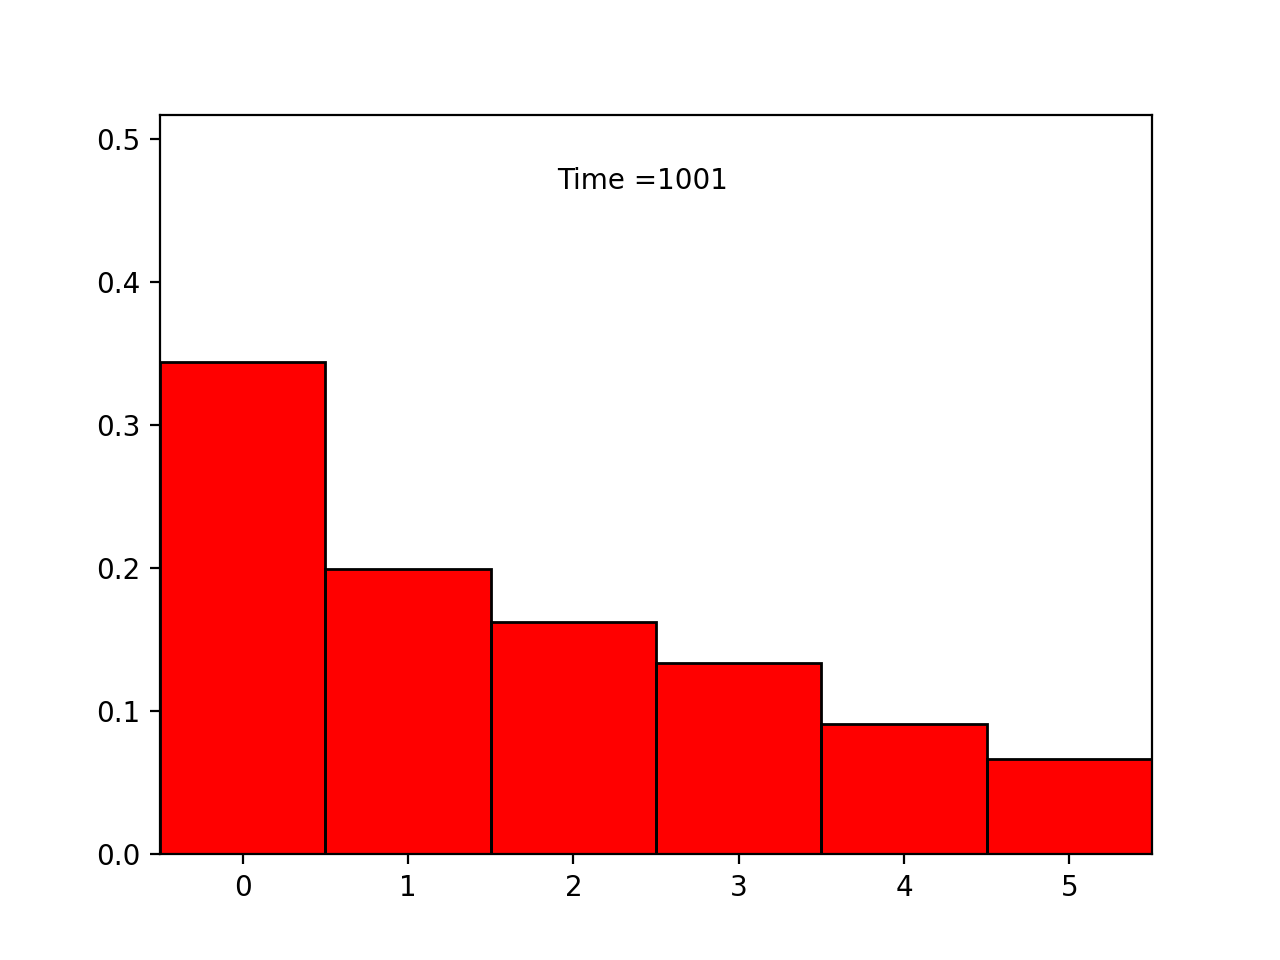

In [11]:
Qplot(qdata) # animation of given qdata without pi given

In [12]:
print(pi)

[0.36541353 0.24360902 0.16240602 0.10827068 0.07218045 0.0481203 ]


<IPython.core.display.Javascript object>


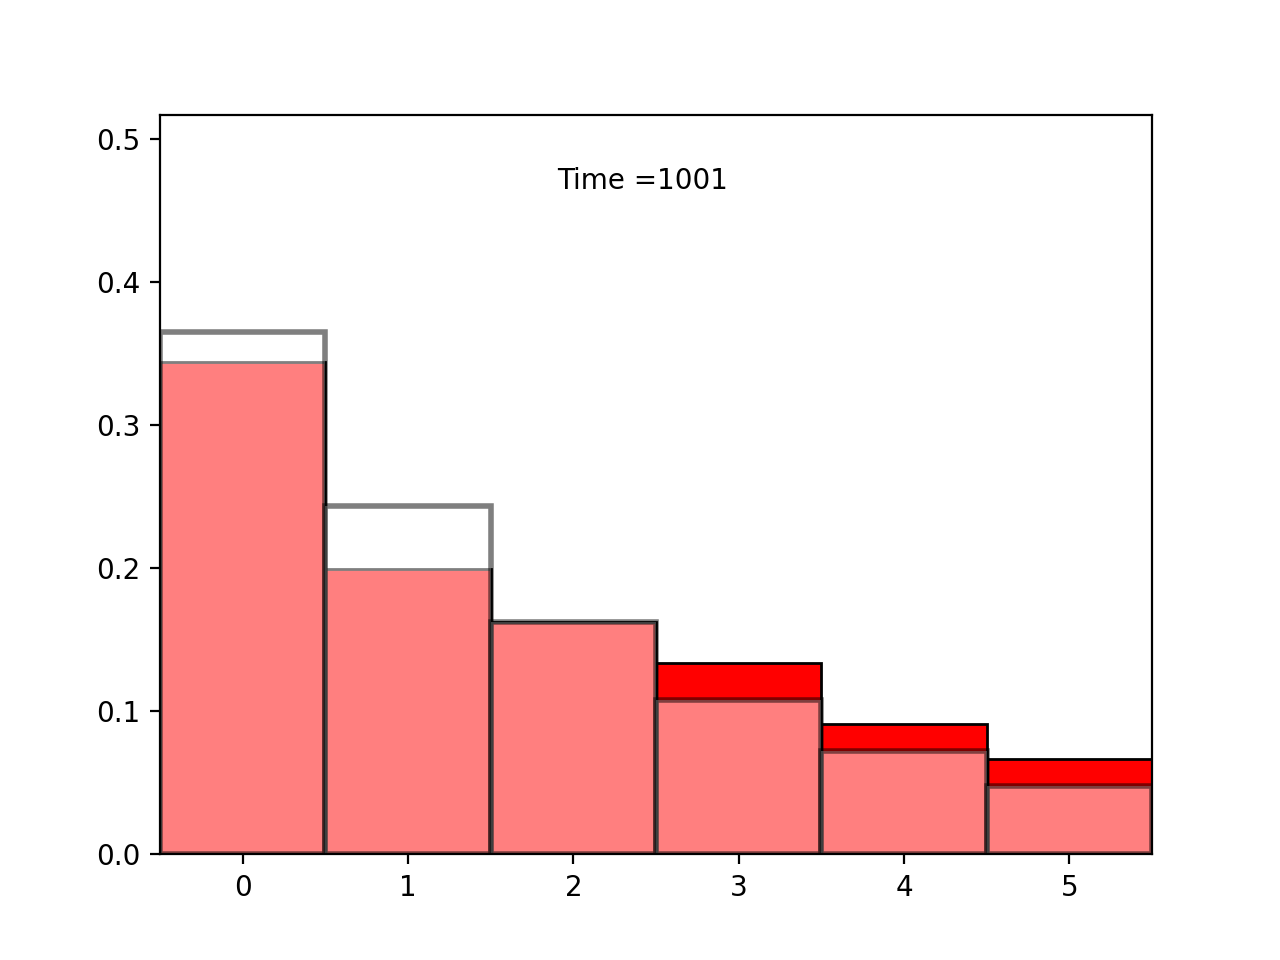

In [13]:
Qplot(qdata,pi) # animation of given qdata with pi given

### Q.1 
Simulate the Markov process with transition matrix: 
$$
\begin{bmatrix} 
1/2 & 0 & 1/2 & 0 & 0 & 0 \\ 
0 & 1/2 & 0 & 1/2 & 0 & 0 \\ 
0 & 0 & 1/2 & 0 & 1/2 & 0 \\ 
0 & 1/4 & 0 & 1/2 & 0 & 1/4 \\ 
1/4 & 0 & 1/4 & 0 & 1/2 & 0 \\ 
0 & 0 & 0 & 1/2 & 0 & 1/2%
\end{bmatrix}
$$

This is the same example as in Q.3 of Practical 1. Observe the long-time behaviour for initial queue size 0 and initial queue size 1. 

Observe what happens if the first row of the transition matrix is changed to $[1/4 , 1/4 , 1/2 , 0 , 0 , 0]$

In [14]:
P=np.array([
    [1/2,0,1/2,0,0,0],
    [0,1/2,0,1/2,0,0],
    [0,0,1/2,0,1/2,0],
    [0,1/4,0,1/2,0,1/4],
    [1/4,0,1/4,0,1/2,0],
    [0,0,0,1/2,0,1/2]
    ])
print(P)

[[0.5  0.   0.5  0.   0.   0.  ]
 [0.   0.5  0.   0.5  0.   0.  ]
 [0.   0.   0.5  0.   0.5  0.  ]
 [0.   0.25 0.   0.5  0.   0.25]
 [0.25 0.   0.25 0.   0.5  0.  ]
 [0.   0.   0.   0.5  0.   0.5 ]]


In [15]:
Equilibrium(P)

ERROR: P is not Ergodic


array([0., 0., 0., 0., 0., 0.])

In [16]:
qdata=Queue(P,0,1000)  # 1000 iterations with initial state 0

In [17]:
print(qdata)

[0, 0, 2, 4, 2, 4, 0, 2, 2, 2, 2, 4, 2, 4, 4, 2, 4, 2, 2, 2, 4, 0, 0, 2, 4, 0, 0, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 0, 2, 4, 0, 2, 2, 2, 4, 0, 0, 0, 2, 2, 2, 4, 0, 0, 2, 4, 0, 0, 0, 2, 4, 2, 4, 4, 0, 0, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 4, 4, 2, 4, 4, 2, 2, 4, 4, 0, 0, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2, 4, 4, 4, 2, 4, 4, 0, 0, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 4, 4, 4, 0, 2, 4, 4, 4, 0, 0, 2, 4, 0, 2, 2, 4, 0, 0, 2, 4, 4, 0, 0, 2, 2, 2, 2, 4, 4, 0, 0, 2, 2, 4, 4, 4, 0, 2, 2, 4, 2, 2, 4, 2, 4, 4, 2, 2, 4, 2, 4, 4, 0, 0, 2, 2, 4, 0, 0, 2, 2, 4, 4, 4, 0, 2, 2, 2, 4, 4, 2, 4, 0, 0, 2, 2, 2, 4, 4, 2, 2, 2, 4, 4, 4, 2, 4, 4, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 4, 4, 0, 0, 0, 0, 2, 2, 4, 0, 2, 4, 0, 0, 2, 2, 2, 4, 4, 0, 2, 2, 2, 2, 2, 4, 2, 4, 0, 2, 2, 4, 0, 2, 2, 2, 4, 4, 4, 2, 4, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 4, 2, 4, 4, 2, 4, 4, 4, 0, 0, 2, 4, 4, 2, 4, 0, 2, 2, 4, 4, 4, 4, 4, 2, 4, 4, 2, 4, 0, 2, 4, 4, 0, 2, 4, 4, 2, 4, 4, 4, 4, 0, 0, 2, 4, 4, 0, 0, 0, 0, 2, 4, 0, 2, 2, 2, 2, 4, 

<IPython.core.display.Javascript object>


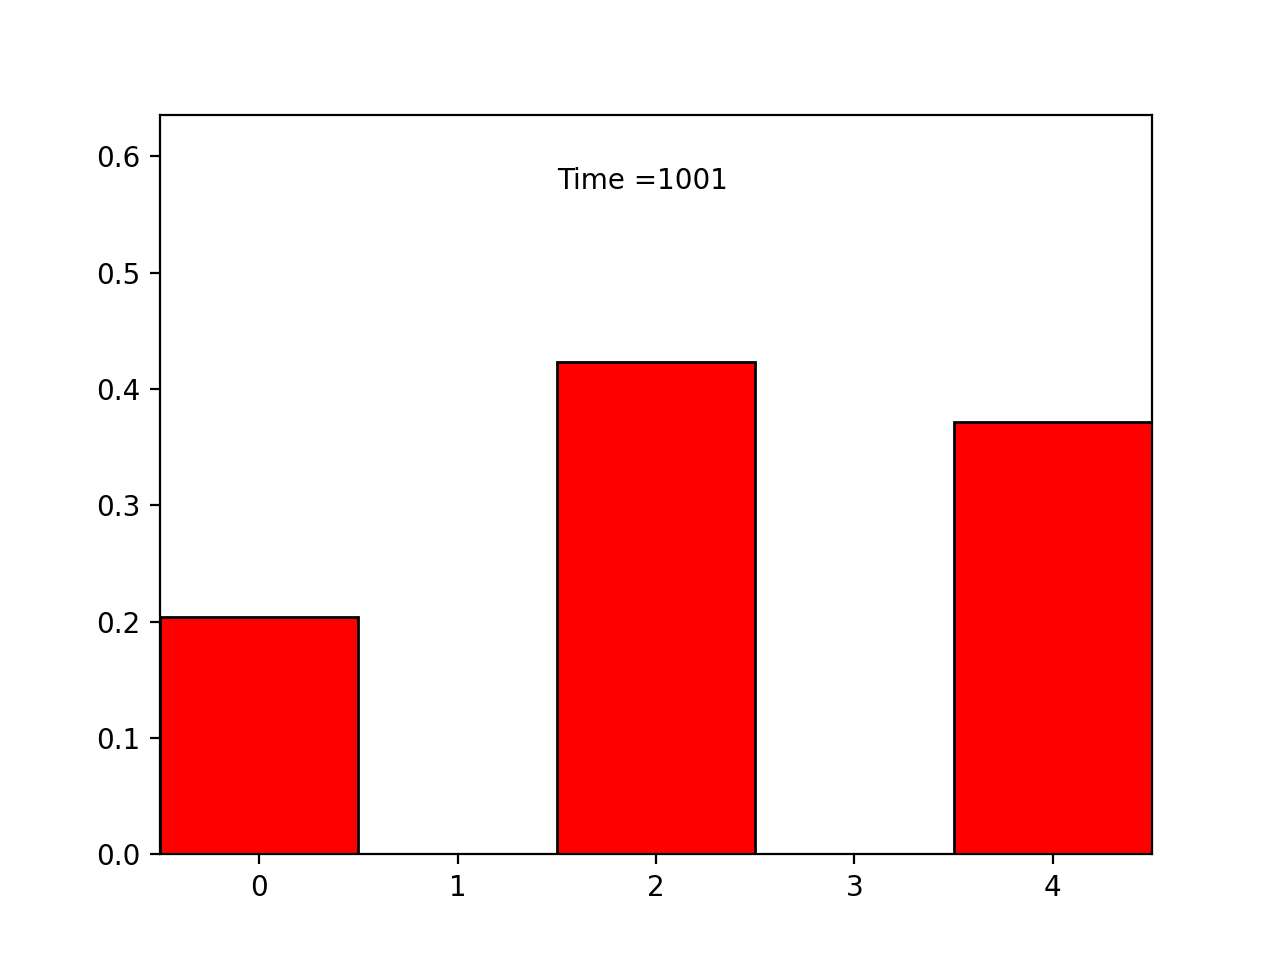

In [18]:
Qplot(qdata)

We can see that when the initial queue size is 0, the queue alternates between queue sizes 0, 2 and 4. This shows that the queue is not ergodic, as the sizes of 1, 3 and 5 are never reached.

In [19]:
qdata=Queue(P,1,1000)  # 1000 iterations with initial state 1

<IPython.core.display.Javascript object>


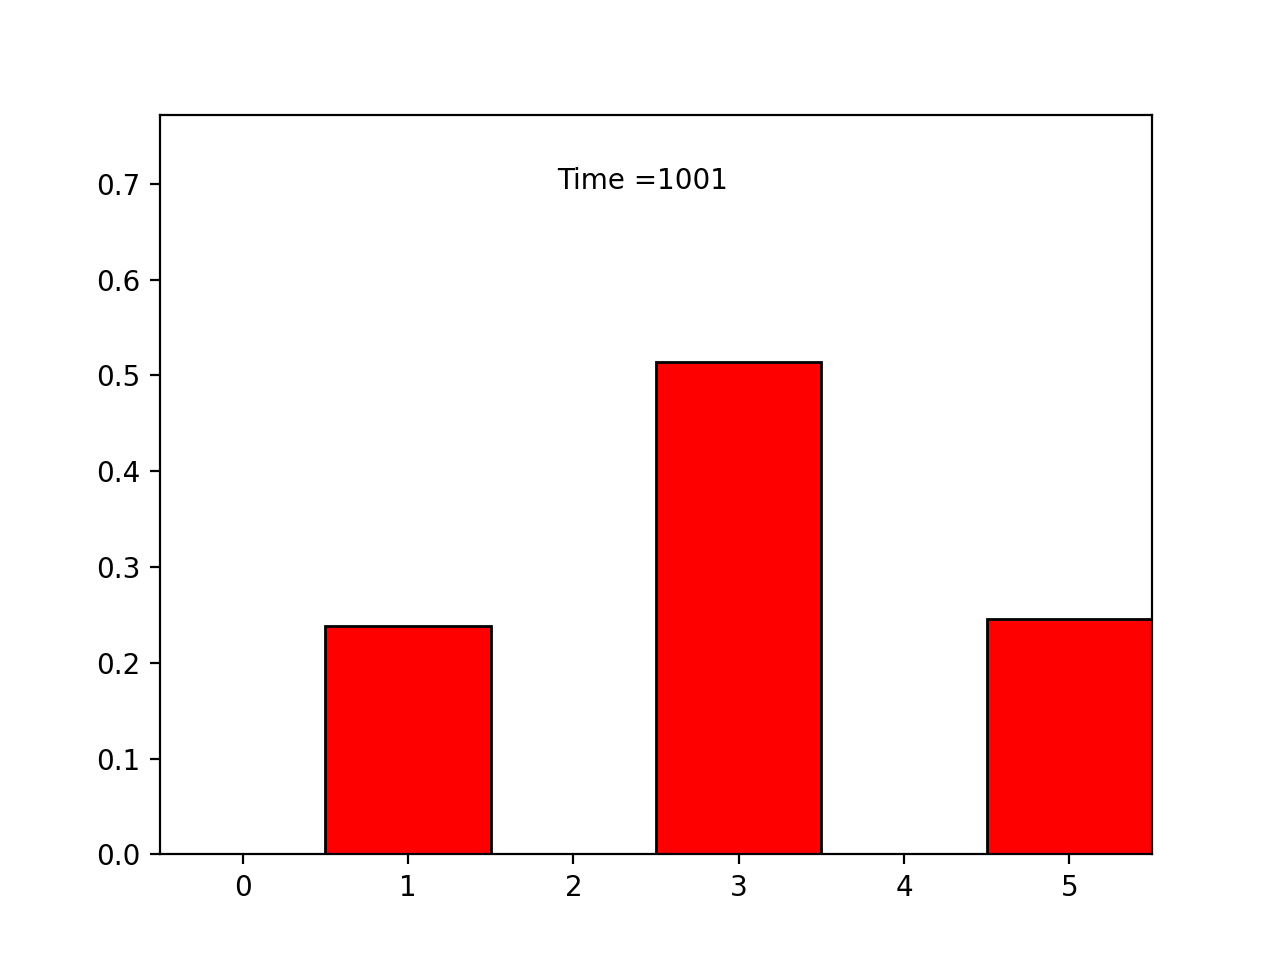

In [20]:
Qplot(qdata)

We can see that when the initial queue size is 1, the queue alternates between queue sizes 1, 3 and 5. This shows that the queue is not ergodic, as the sizes of 0,2, and 4 are never reached.


This behaviour is what is expected after Equilbrium(P) showing that the queue is not ergodic as there is not a single eigenvector of value 1.

In [21]:
#Change first row of the transition matrix

P[0] = [0.25,0.25, 0.5, 0, 0, 0]

print(P)


[[0.25 0.25 0.5  0.   0.   0.  ]
 [0.   0.5  0.   0.5  0.   0.  ]
 [0.   0.   0.5  0.   0.5  0.  ]
 [0.   0.25 0.   0.5  0.   0.25]
 [0.25 0.   0.25 0.   0.5  0.  ]
 [0.   0.   0.   0.5  0.   0.5 ]]


In [22]:
qdata1=Queue(P,0,1000)

<IPython.core.display.Javascript object>


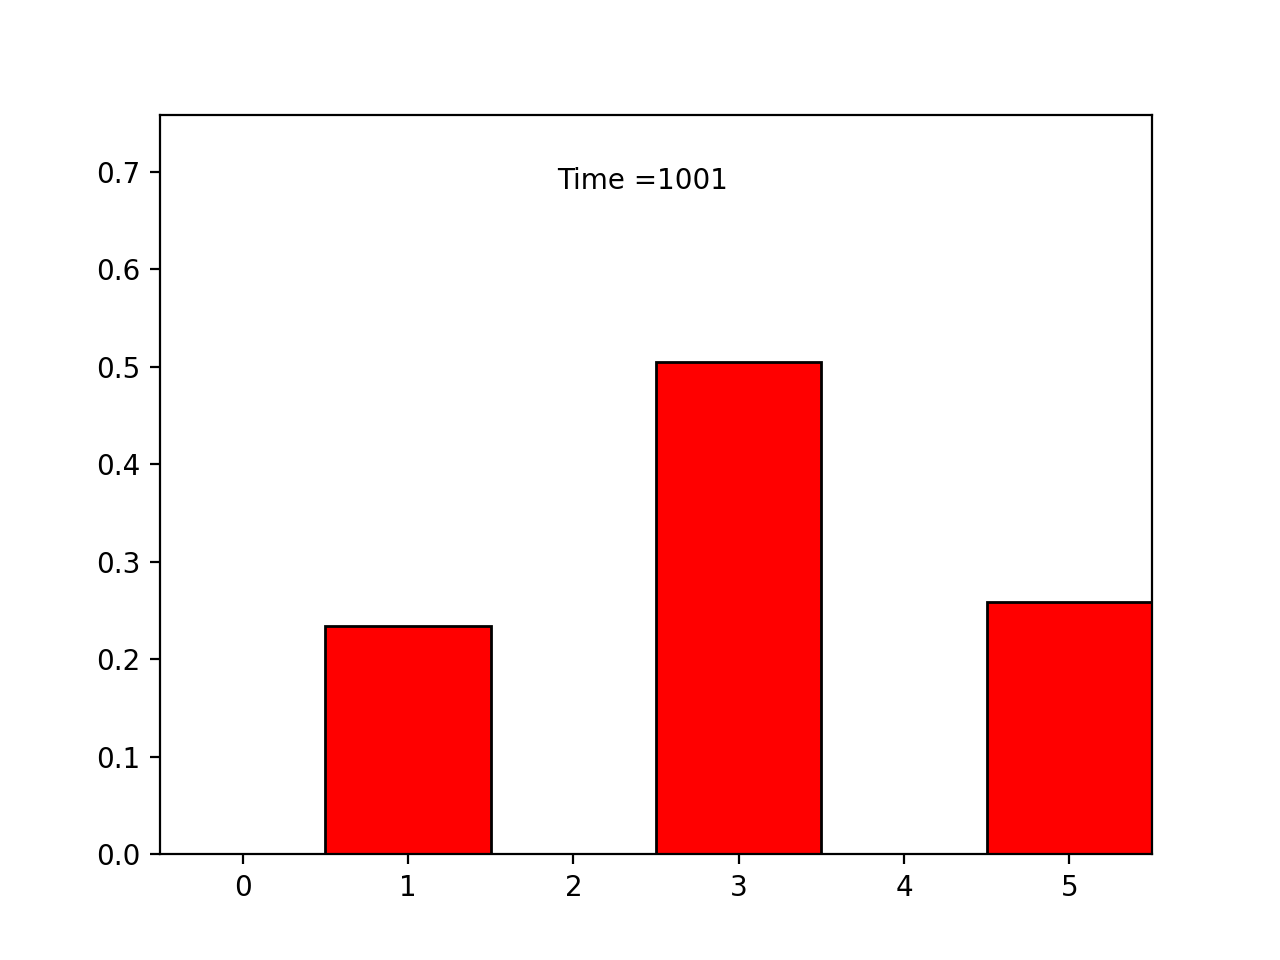

In [23]:
Qplot(qdata1)

In [24]:
qdata1=Queue(P,1,1000)

<IPython.core.display.Javascript object>


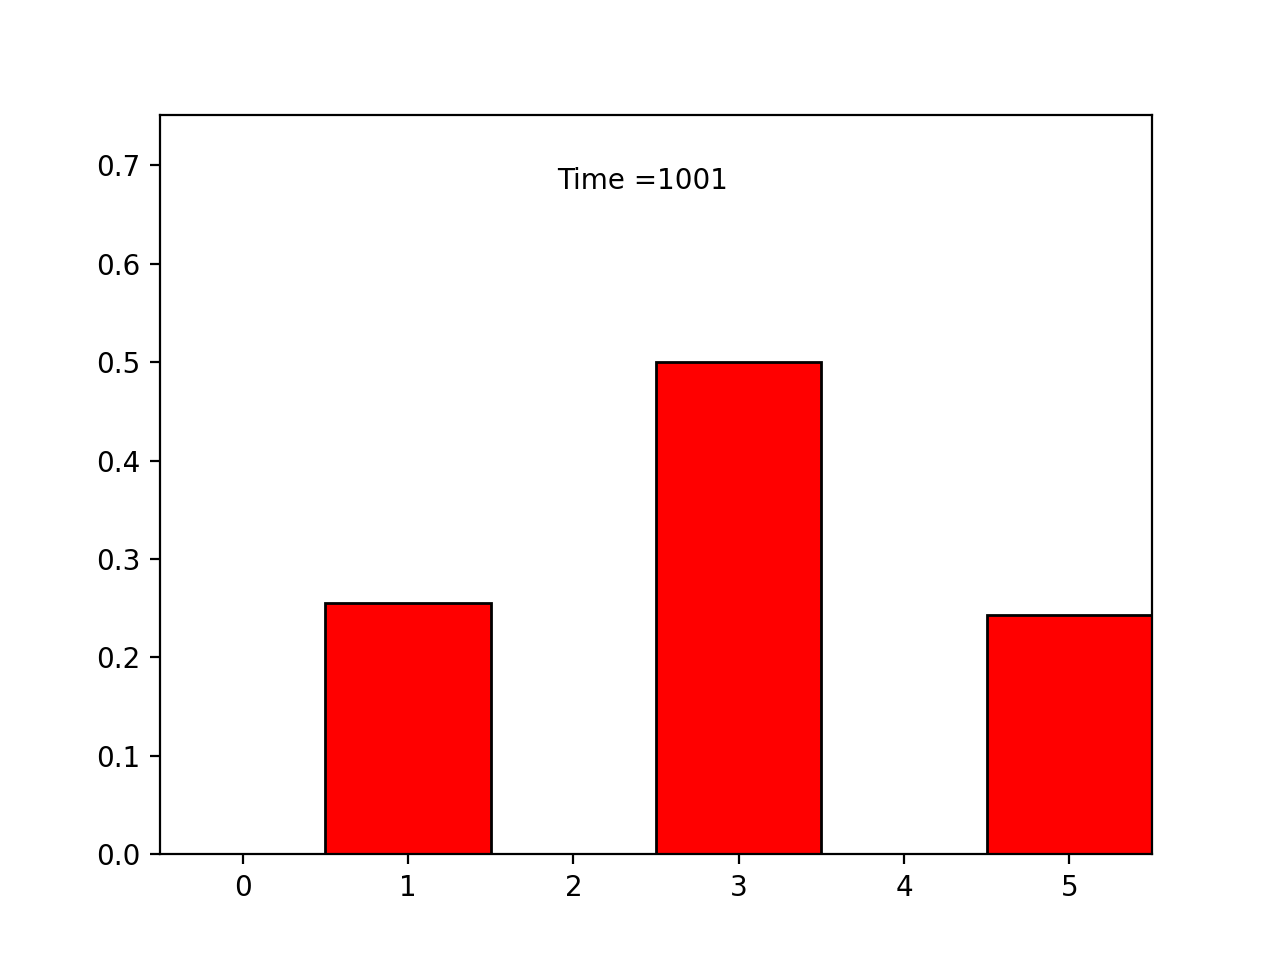

In [25]:
Qplot(qdata1)

In [26]:
X, V = np.linalg.eig(P)
print(X)

[ 9.61366523e-01+0.j         1.44316739e-01+0.2769298j
  1.44316739e-01-0.2769298j -1.11022302e-16+0.j
  1.00000000e+00+0.j         5.00000000e-01+0.j       ]


From the eigenvalue of 1, we can see that P is now ergodic after changing the first row of the transition matrix. The equilibrium probabilites are given by the eigenvector corresponding to the eigenvalue of 1. 

In [27]:
Equilibrium(P)


array([1.20186574e-15, 2.50000000e-01, 3.34130169e-15, 5.00000000e-01,
       3.36535639e-15, 2.50000000e-01])

Examining the simulations and the transition matrix we see that an initial state of 0, 2 or 4 allows the queue to visit all other sizes from 0 to 5.

An initial state of 1, however, limits the queue to lengths 1, 3 and 5.

## Q.2(*)
A queue is observed 1000 time intervals with data as given in the array `qdata` below. 
This is the same as Question 4 of Practical 1.

Compare the actual frequencies of events with a simulated one. Use the probabilities found in Practical 1. 

Look at that question again for examples of do loops and if else statements in Python

In [28]:
qdata = [4, 5, 6, 6, 6, 7, 6, 7, 6, 5, 4, 4, 5, 6, 7, 6, 5, 4, 3, 4, 5, 6, 5, 4, 3, 2, 1, 2, 3, 2, 1, 
         2, 3, 4, 3, 2, 3, 2, 1, 1, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 2, 3, 4, 5, 4, 5, 6, 7, 
         8, 7, 6, 7, 6, 6, 5, 4, 5, 4, 3, 2, 3, 2, 3, 2, 3, 2, 1, 1, 2, 3, 3, 4, 5, 6, 7, 6, 5, 6, 5, 
         6, 5, 6, 5, 4, 5, 4, 3, 4, 3, 4, 3, 2, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 3, 3, 2, 3, 4, 3, 2, 
         3, 2, 1, 2, 3, 2, 3, 2, 1, 0, 0, 1, 1, 2, 3, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 2, 
         1, 2, 3, 4, 3, 4, 5, 6, 5, 6, 5, 6, 7, 7, 6, 5, 4, 3, 4, 3, 3, 4, 3, 2, 3, 2, 3, 2, 1, 2, 1, 
         2, 1, 0, 0, 0, 0, 1, 2, 3, 2, 2, 3, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 
         0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 0, 0, 1, 2, 3, 2, 3, 3, 4, 5, 6, 5, 4, 3, 2, 1, 2, 
         1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 
         1, 0, 0, 1, 2, 3, 2, 3, 2, 2, 3, 4, 4, 5, 4, 3, 2, 3, 2, 3, 2, 3, 2, 1, 0, 1, 2, 3, 2, 1, 2, 
         1, 0, 1, 0, 1, 2, 3, 3, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 3, 2, 2, 1, 0, 1, 2, 1, 2, 3, 4, 4, 3, 
         2, 2, 1, 2, 3, 4, 5, 4, 4, 5, 4, 3, 4, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 2, 
         1, 2, 2, 3, 2, 3, 4, 5, 6, 5, 6, 5, 4, 5, 6, 7, 6, 5, 6, 6, 7, 6, 7, 7, 6, 7, 6, 5, 4, 5, 5, 
         4, 5, 6, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5, 4, 3, 4, 5, 6, 5, 4, 3, 3, 4, 3, 2, 3, 2, 3, 3, 2, 1, 
         2, 1, 0, 0, 0, 0, 0, 1, 2, 3, 2, 3, 4, 5, 6, 7, 7, 8, 9, 8, 9, 8, 7, 6, 5, 5, 4, 5, 4, 3, 2, 
         1, 0, 1, 2, 1, 2, 3, 4, 5, 6, 7, 7, 8, 7, 8, 9, 8, 7, 6, 5, 4, 3, 4, 3, 4, 4, 5, 4, 3, 4, 3, 
         2, 3, 2, 3, 3, 2, 1, 1, 0, 1, 2, 1, 2, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1, 0, 1, 0, 1, 0, 0, 1, 2, 
         3, 2, 1, 0, 0, 1, 2, 3, 4, 3, 2, 3, 2, 2, 1, 0, 1, 0, 0, 1, 0, 1, 2, 3, 4, 5, 6, 7, 6, 7, 7, 
         6, 7, 8, 8, 9, 10, 9, 10, 9, 10, 11, 10, 9, 8, 9, 10, 11, 10, 10, 9, 10, 10, 9, 8, 7, 8, 9, 10,
         9, 8, 7, 6, 7, 6, 7, 6, 5, 4, 4, 5, 4, 3, 2, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 0, 
         0, 0, 1, 0, 0, 1, 0, 1, 2, 3, 2, 3, 2, 3, 4, 3, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 3, 2, 
         2, 2, 1, 0, 1, 2, 3, 4, 5, 4, 5, 4, 3, 2, 3, 4, 5, 5, 4, 3, 4, 3, 4, 5, 4, 3, 2, 1, 0, 1, 2, 
         3, 4, 3, 2, 3, 4, 3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 1, 0, 1, 2, 3, 4, 5, 4, 5, 4, 5, 6, 5, 4, 5, 
         6, 5, 4, 3, 2, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 3, 4, 3, 4, 3, 2, 1, 1, 2, 3, 2, 3, 2, 3, 2, 3, 
         4, 3, 4, 4, 5, 6, 7, 6, 7, 7, 6, 5, 4, 3, 4, 3, 2, 2, 3, 4, 3, 4, 3, 2, 1, 0, 0, 1, 2, 3, 2, 
         1, 2, 3, 2, 1, 0, 0, 0, 0, 1, 1, 2, 3, 2, 3, 2, 3, 4, 5, 6, 5, 5, 4, 3, 4, 5, 4, 3, 4, 5, 4, 
         3, 2, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0, 1, 0, 0, 1, 2, 3, 2, 3, 2, 3, 3, 4, 
         3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 3, 2, 3, 2, 1, 0, 
         0, 0, 1, 2, 2, 3, 3, 2, 3, 4, 3, 2, 1, 2, 3, 3, 2, 1, 0, 1, 2, 2, 3, 4, 5, 6, 7, 7, 6, 5, 4, 
         5, 4, 5, 4, 3, 2, 3, 4, 3, 2, 1, 2, 3, 4, 3, 2, 3, 2, 1, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 
         0, 1, 2, 2, 3, 2, 1, 0, 1, 2, 3, 4, 4, 3, 4, 3, 2, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 
         0, 0, 1, 0, 1, 2, 2, 3, 3, 4, 3, 2, 3, 2, 1, 0, 0, 1, 2, 1, 2, 3, 2, 1, 2, 3, 2, 3, 2, 1, 0, 
         1, 2, 1, 2, 3, 2, 3, 2, 1, 1, 0]

In [29]:
N = len(qdata)

In [30]:
nup=0 # nup counts no of up steps
ndown=0 # ndown counts no of down steps
n0 = 0

for i in range(1,N):
    if qdata[i]>qdata[i-1]:
        nup=nup+1
    elif qdata[i]<qdata[i-1]:
        ndown=ndown+1
    if qdata[i-1]==0:
        n0=n0+1
print(nup, "up steps", ndown, "down steps", n0, "steps at bottom")

417 up steps 421 down steps 170 steps at bottom


In [31]:
pup = nup/(N-1)
pdown = ndown/(N-1-n0)
print("pup:", pup,"pdown:",pdown)

pup: 0.4174174174174174 pdown: 0.5078407720144753


We can see that the probability of the queue increasing (pup) is 0.417, and the probability of the queue decreasing (pdown) is 0.508. 

Since there is a higher probability of the queue decreasing, the expected behaviour is for the queue to be most commonly found at 0.

In [32]:
qsize = max(qdata) + 1 #Estimate max queue size based on the data given

P = Nearneigh(pup, pdown, qsize)
pi2 = Equilibrium(P)

In [33]:
print("Equilbrium probabilities:\n", pi2)

Equilbrium probabilities:
 [0.19315028 0.15875899 0.13049123 0.10725668 0.08815914 0.072462
 0.05955982 0.04895492 0.04023827 0.03307367 0.02718475 0.02234438
 0.01836586]


<IPython.core.display.Javascript object>


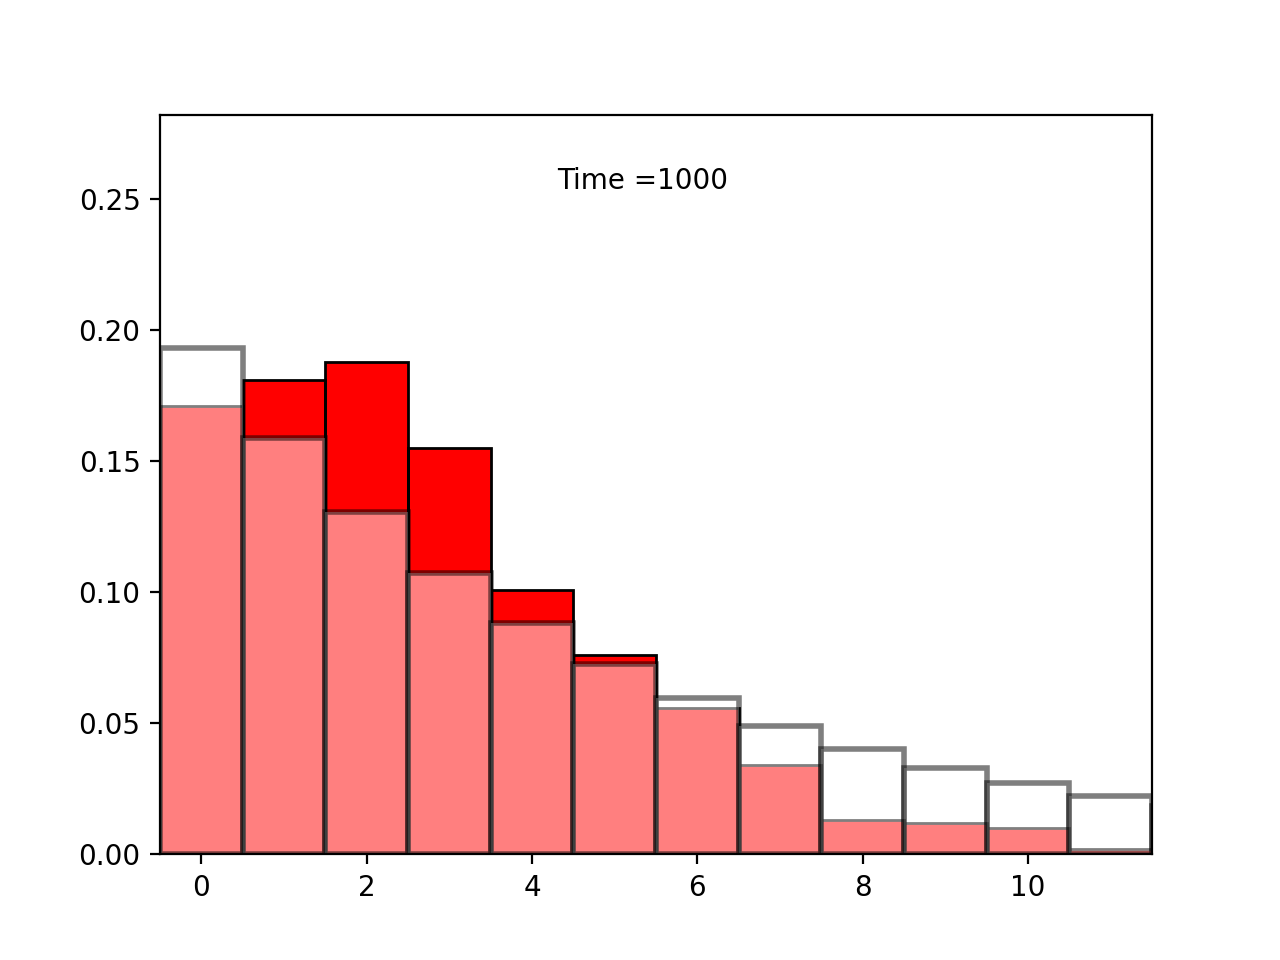

In [34]:
Qplot(qdata, pi2)

In [35]:
qdata2 = Queue(P, 4, 5000)

<IPython.core.display.Javascript object>


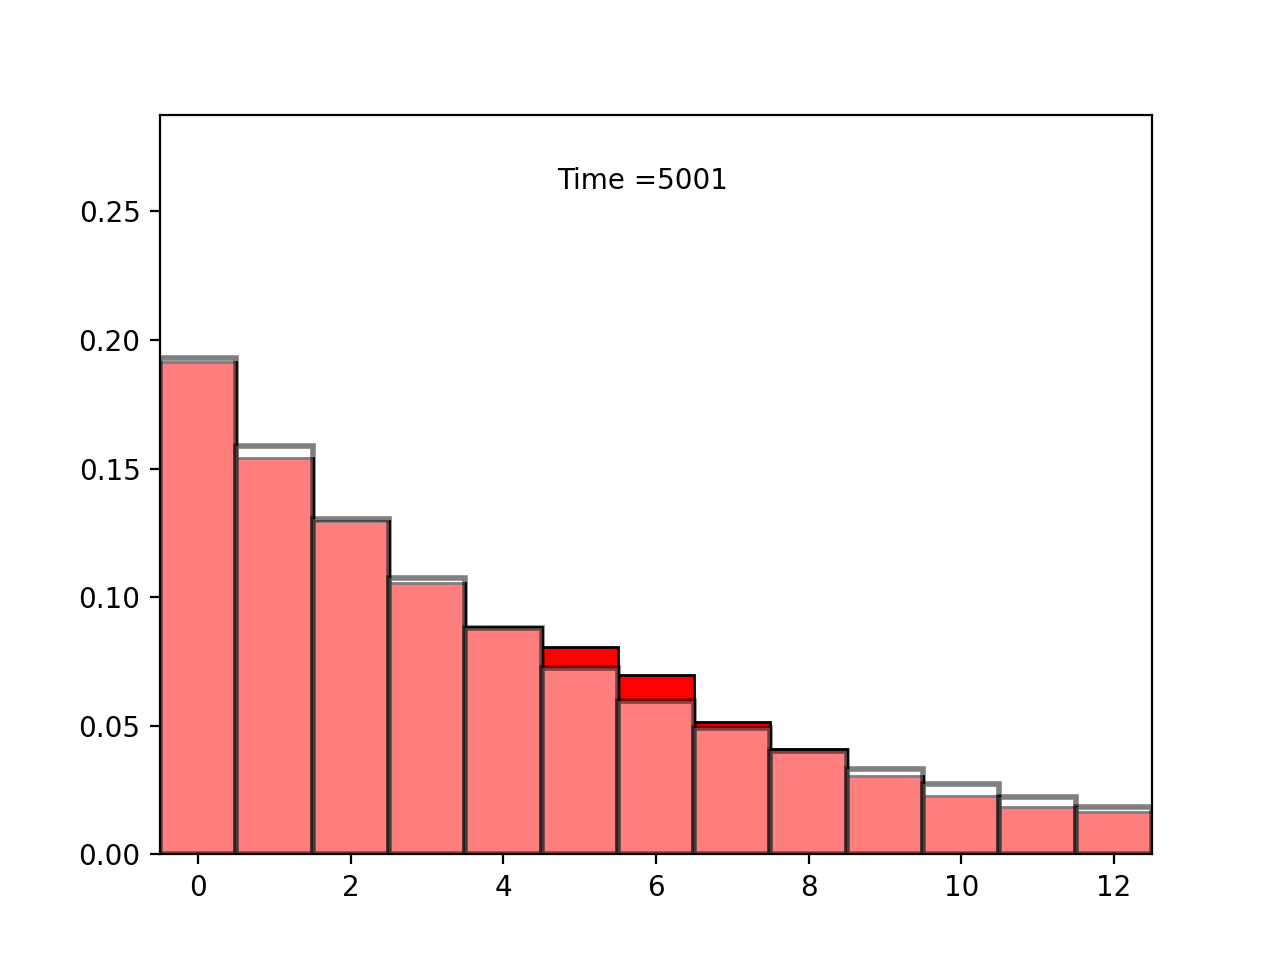

In [36]:
Qplot(qdata2, pi2)

Comparing the original qdata to the equilibrium probabilities, we  can see that the observed queue sizes very roughly follow the expected queue sizes in the frequency graph.

Simulating a queue over 5000 time intervals and comparing the simulated frequencies to the equilibrium probability, we see that the more data points we have the more accurately the observed frequencies follow the expected values.

## Q.3(*)
A queue is observed 10000 time intervals with data as given in the array `qdata` below. 
This is the same as Question Question 5 of Practical 1.

(a) Construct a simple model for this queue as a Markov chain with only nearest neighbour interactions.
 1. Estimate the transition probabilities.
 2. What is the expected behaviour of the queue as time continues?
 3. Is the system ergodic ?

(b) Suppose that the time step used is known to be 10 sec.
 1. What is the average waiting time for customer service/arrival?
 2. What is average number of servicings/arrivals per minute?

(c) Simulate this system and compare the actual frequencies of events with the simulated ones.
  
  


In [37]:
qdata = [5, 5, 5, 6, 5, 6, 6, 7, 6, 5, 6, 5, 4, 5, 6, 6, 6, 7, 8, 7, 6, 6, 6, 5, 4, 4, 5, 5, 4, 5, 6, 6, 5, 4, 3, 3, 2, 2, 1, 2, 2, 3, 3, 2, 3, 4, 3, 2, 3, 3, 4, 4, 3, 4, 3, 3, 4, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 6, 7, 6, 5, 4, 4, 3, 3, 2, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 2, 3, 4, 4, 3, 2, 2, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 3, 2, 1, 2, 1, 2, 1, 2, 3, 4, 5, 5, 6, 5, 6, 5, 4, 4, 4, 3, 2, 2, 1, 2, 2, 3, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 2, 2, 2, 1, 2, 1, 1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 3, 4, 3, 2, 1, 2, 3, 3, 2, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 1, 2, 3, 4, 5, 6, 6, 7, 6, 5, 4, 5, 5, 4, 3, 2, 1, 0, 0, 1, 0, 1, 1, 2, 2, 3, 2, 1, 2, 3, 2, 3, 4, 4, 4, 5, 6, 7, 6, 5, 4, 3, 3, 2, 3, 3, 2, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 2, 2, 3, 2, 1, 2, 1, 1, 1, 2, 3, 4, 4, 3, 3, 2, 1, 2, 3, 4, 5, 4, 5, 6, 5, 4, 4, 4, 4, 3, 2, 1, 1, 2, 2, 1, 1, 0, 1, 1, 2, 3, 2, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 2, 2, 2, 2, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 2, 2, 2, 2, 3, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 2, 1, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 3, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 3, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 3, 3, 4, 4, 4, 4, 3, 4, 4, 4, 5, 4, 5, 5, 5, 4, 3, 4, 4, 5, 6, 7, 6, 6, 7, 7, 6, 7, 7, 7, 7, 8, 8, 7, 7, 8, 9, 10, 11, 10, 11, 10, 9, 8, 8, 7, 8, 9, 8, 8, 7, 7, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 5, 5, 6, 7, 8, 7, 7, 6, 5, 4, 4, 3, 3, 4, 5, 5, 4, 3, 2, 3, 4, 4, 4, 4, 4, 3, 3, 4, 5, 5, 6, 6, 6, 6, 6, 5, 5, 4, 4, 3, 2, 2, 1, 0, 1, 2, 2, 3, 2, 3, 3, 2, 1, 2, 3, 2, 1, 2, 2, 3, 4, 4, 4, 5, 6, 5, 6, 7, 6, 6, 5, 4, 3, 3, 4, 4, 5, 4, 4, 5, 4, 3, 2, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 3, 4, 5, 4, 3, 3, 2, 3, 3, 3, 4, 3, 4, 5, 6, 7, 8, 9, 10, 10, 11, 12, 12, 11, 11, 10, 11, 11, 11, 10, 9, 9, 10, 10, 9, 8, 8, 7, 7, 6, 7, 8, 8, 8, 8, 7, 8, 7, 7, 6, 5, 6, 6, 6, 7, 8, 7, 7, 6, 6, 5, 5, 6, 7, 7, 7, 6, 7, 8, 9, 8, 7, 7, 6, 6, 6, 7, 8, 9, 9, 10, 11, 11, 12, 12, 13, 14, 14, 15, 16, 15, 15, 16, 15, 14, 13, 14, 15, 14, 13, 14, 15, 15, 14, 14, 13, 14, 14, 15, 14, 15, 14, 13, 12, 12, 11, 12, 12, 13, 13, 14, 14, 15, 15, 15, 16, 17, 18, 17, 17, 18, 19, 19, 18, 17, 16, 17, 18, 18, 18, 17, 18, 17, 16, 15, 14, 13, 12, 12, 13, 12, 12, 12, 11, 11, 10, 11, 12, 11, 12, 11, 11, 10, 10, 10, 9, 8, 9, 10, 9, 9, 8, 8, 9, 8, 8, 8, 7, 7, 8, 9, 10, 10, 11, 10, 11, 12, 12, 11, 10, 10, 11, 11, 11, 10, 11, 11, 10, 9, 10, 11, 10, 11, 12, 12, 11, 10, 9, 8, 8, 9, 8, 7, 8, 8, 8, 9, 9, 10, 11, 11, 12, 11, 10, 10, 9, 8, 9, 10, 11, 12, 12, 13, 12, 13, 12, 11, 10, 11, 10, 11, 10, 9, 8, 8, 7, 6, 7, 6, 6, 7, 8, 8, 7, 6, 7, 6, 6, 5, 4, 4, 3, 2, 3, 4, 3, 4, 4, 3, 4, 3, 3, 2, 2, 2, 2, 2, 3, 2, 1, 1, 2, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 3, 4, 4, 5, 5, 4, 4, 3, 3, 2, 1, 2, 1, 1, 2, 3, 2, 1, 2, 2, 1, 2, 1, 0, 1, 2, 3, 2, 3, 4, 4, 3, 4, 3, 3, 2, 2, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 3, 3, 4, 3, 3, 2, 1, 1, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 2, 3, 3, 2, 2, 3, 4, 5, 5, 5, 5, 4, 5, 4, 5, 4, 4, 4, 3, 4, 3, 4, 5, 4, 5, 4, 3, 2, 3, 2, 3, 4, 3, 4, 5, 6, 6, 5, 5, 5, 6, 5, 6, 6, 7, 7, 8, 9, 10, 9, 10, 11, 12, 12, 13, 13, 13, 12, 12, 12, 11, 11, 10, 10, 9, 8, 7, 6, 6, 7, 7, 8, 8, 9, 10, 9, 8, 9, 10, 10, 10, 10, 10, 11, 11, 11, 11, 12, 13, 13, 12, 12, 11, 12, 11, 10, 9, 8, 7, 7, 8, 7, 8, 7, 7, 7, 6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 7, 6, 5, 6, 5, 5, 4, 5, 5, 6, 6, 7, 6, 5, 4, 4, 3, 2, 3, 2, 1, 0, 0, 0, 1, 0, 1, 2, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1, 2, 3, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 1, 0, 1, 1, 2, 3, 3, 3, 2, 2, 3, 4, 5, 5, 4, 4, 5, 5, 6, 5, 5, 6, 5, 4, 5, 4, 5, 6, 5, 5, 4, 5, 5, 6, 7, 7, 7, 8, 9, 9, 8, 7, 6, 5, 4, 5, 4, 5, 4, 5, 5, 4, 3, 4, 5, 4, 4, 3, 3, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 2, 2, 3, 2, 2, 3, 3, 3, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 3, 4, 5, 4, 3, 3, 4, 3, 2, 2, 1, 0, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 2, 2, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 2, 3, 4, 5, 5, 4, 3, 4, 4, 4, 4, 3, 3, 4, 5, 4, 5, 5, 4, 5, 6, 5, 6, 5, 5, 6, 6, 5, 6, 6, 7, 6, 5, 5, 5, 4, 5, 4, 3, 3, 3, 3, 4, 3, 4, 5, 4, 3, 4, 3, 2, 2, 1, 1, 2, 3, 2, 3, 3, 4, 4, 5, 4, 5, 6, 6, 7, 8, 7, 7, 7, 8, 9, 9, 8, 9, 8, 9, 8, 7, 7, 6, 6, 7, 8, 9, 9, 10, 9, 8, 7, 7, 6, 5, 5, 4, 3, 3, 4, 5, 6, 6, 7, 7, 8, 9, 9, 10, 10, 10, 11, 12, 13, 14, 15, 14, 15, 14, 13, 13, 13, 14, 15, 15, 14, 13, 13, 13, 12, 12, 12, 13, 12, 12, 13, 12, 11, 12, 11, 10, 10, 9, 8, 8, 9, 9, 10, 11, 11, 10, 10, 9, 9, 9, 9, 10, 10, 9, 10, 11, 10, 11, 11, 11, 10, 10, 11, 12, 11, 12, 13, 12, 11, 12, 11, 10, 10, 9, 9, 10, 11, 10, 11, 10, 10, 9, 9, 9, 9, 8, 9, 8, 9, 10, 10, 9, 8, 7, 8, 7, 6, 5, 6, 5, 4, 5, 5, 6, 5, 4, 5, 5, 4, 3, 4, 3, 2, 1, 2, 3, 3, 3, 2, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2, 3, 2, 3, 4, 3, 2, 2, 2, 2, 2, 1, 2, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 3, 3, 4, 3, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 3, 3, 3, 4, 4, 4, 3, 3, 2, 3, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 2, 3, 3, 3, 3, 3, 2, 3, 4, 3, 2, 2, 3, 3, 2, 2, 2, 1, 2, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 3, 2, 2, 1, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 3, 4, 4, 4, 4, 5, 5, 4, 5, 4, 5, 6, 7, 8, 8, 7, 6, 7, 7, 8, 8, 7, 6, 7, 7, 7, 6, 6, 7, 7, 8, 9, 8, 7, 6, 7, 7, 8, 8, 7, 8, 9, 10, 9, 10, 11, 12, 11, 11, 12, 11, 10, 10, 10, 10, 11, 10, 11, 12, 12, 12, 12, 12, 12, 11, 12, 11, 11, 10, 9, 9, 8, 8, 7, 6, 7, 7, 6, 7, 6, 7, 6, 5, 6, 7, 7, 7, 8, 8, 9, 8, 7, 6, 5, 4, 5, 6, 7, 7, 6, 7, 8, 7, 8, 8, 8, 7, 8, 7, 6, 6, 5, 5, 6, 6, 5, 6, 7, 6, 7, 6, 6, 5, 5, 6, 5, 6, 6, 7, 7, 6, 7, 7, 8, 9, 9, 8, 7, 8, 7, 6, 7, 8, 9, 10, 11, 10, 9, 9, 9, 8, 9, 8, 7, 6, 6, 7, 6, 5, 4, 3, 2, 3, 4, 3, 2, 2, 2, 3, 4, 3, 3, 4, 3, 2, 3, 4, 4, 4, 3, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3, 2, 3, 2, 1, 2, 3, 2, 2, 1, 2, 2, 3, 2, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 3, 2, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 3, 3, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 2, 3, 2, 3, 3, 2, 1, 0, 0, 0, 0, 0, 1, 2, 3, 2, 2, 3, 2, 1, 0, 1, 1, 2, 3, 2, 2, 3, 3, 3, 3, 3, 4, 3, 2, 3, 2, 2, 3, 3, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 2, 2, 2, 3, 2, 1, 1, 1, 1, 2, 3, 4, 4, 4, 4, 5, 6, 5, 4, 4, 3, 3, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 3, 2, 1, 0, 0, 0, 1, 0, 1, 2, 3, 4, 4, 4, 5, 4, 4, 5, 4, 5, 6, 5, 5, 6, 7, 7, 7, 7, 6, 7, 6, 6, 5, 4, 3, 3, 4, 3, 3, 3, 4, 3, 3, 4, 3, 2, 3, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 2, 3, 3, 4, 5, 4, 3, 3, 3, 2, 1, 1, 2, 2, 2, 2, 3, 2, 2, 2, 1, 2, 3, 4, 4, 3, 2, 3, 2, 3, 4, 4, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 1, 2, 3, 4, 5, 4, 5, 5, 4, 5, 4, 3, 2, 1, 2, 1, 2, 3, 2, 3, 4, 4, 5, 4, 5, 6, 6, 7, 8, 8, 9, 9, 10, 11, 12, 11, 10, 11, 10, 9, 8, 7, 6, 5, 6, 6, 7, 6, 6, 5, 4, 3, 2, 2, 1, 0, 0, 0, 1, 0, 1, 2, 3, 4, 5, 5, 5, 4, 3, 2, 2, 3, 3, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 3, 2, 2, 2, 3, 3, 3, 4, 3, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 2, 3, 3, 4, 5, 6, 5, 5, 5, 4, 5, 4, 5, 4, 5, 4, 3, 3, 3, 2, 1, 1, 2, 2, 3, 4, 5, 6, 7, 7, 6, 7, 6, 7, 8, 8, 9, 10, 11, 12, 13, 14, 14, 14, 15, 16, 16, 15, 15, 16, 17, 18, 17, 16, 15, 15, 14, 15, 14, 13, 14, 15, 14, 13, 13, 12, 12, 13, 12, 13, 13, 13, 13, 12, 13, 14, 13, 13, 13, 13, 13, 12, 11, 11, 10, 9, 9, 10, 9, 10, 9, 9, 10, 9, 9, 10, 10, 11, 10, 9, 9, 10, 10, 10, 10, 10, 9, 8, 8, 7, 7, 8, 7, 8, 8, 7, 7, 7, 8, 7, 7, 7, 6, 5, 4, 3, 4, 5, 5, 4, 3, 2, 1, 1, 1, 2, 3, 2, 2, 3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0, 1, 2, 2, 2, 2, 3, 2, 1, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 3, 4, 5, 6, 5, 6, 5, 4, 5, 6, 6, 5, 5, 5, 4, 5, 4, 4, 4, 3, 4, 3, 2, 1, 0, 0, 1, 2, 3, 4, 4, 4, 5, 5, 5, 5, 4, 5, 4, 5, 6, 7, 6, 5, 5, 6, 5, 6, 5, 5, 6, 7, 7, 7, 8, 9, 9, 10, 10, 9, 9, 8, 7, 8, 9, 10, 9, 9, 9, 9, 10, 10, 10, 9, 8, 8, 9, 8, 7, 8, 9, 9, 10, 10, 11, 12, 11, 10, 11, 10, 9, 9, 10, 10, 10, 10, 10, 10, 10, 9, 9, 8, 9, 9, 10, 11, 12, 12, 12, 12, 12, 13, 12, 12, 11, 10, 9, 10, 10, 10, 9, 10, 9, 9, 9, 9, 8, 7, 6, 7, 7, 6, 6, 7, 8, 9, 8, 8, 9, 9, 10, 9, 10, 9, 8, 8, 8, 9, 10, 11, 10, 11, 12, 13, 14, 14, 14, 13, 13, 12, 12, 11, 12, 13, 14, 13, 13, 12, 13, 13, 12, 12, 12, 13, 13, 13, 13, 12, 13, 12, 13, 14, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 15, 15, 16, 15, 16, 15, 15, 16, 15, 14, 15, 14, 14, 13, 12, 13, 14, 15, 16, 16, 16, 16, 15, 15, 14, 14, 15, 15, 16, 16, 16, 16, 17, 18, 19, 19, 18, 19, 18, 19, 20, 19, 18, 19, 20, 20, 19, 19, 19, 20, 20, 19, 18, 18, 19, 18, 17, 16, 15, 15, 15, 14, 14, 14, 14, 14, 14, 13, 12, 12, 13, 13, 14, 15, 15, 16, 17, 18, 18, 17, 18, 17, 17, 17, 16, 15, 14, 14, 15, 14, 13, 14, 14, 15, 16, 17, 16, 17, 18, 19, 18, 19, 19, 20, 19, 18, 19, 18, 18, 17, 17, 18, 19, 20, 19, 18, 19, 20, 19, 20, 20, 20, 20, 19, 18, 19, 19, 19, 18, 18, 18, 18, 19, 18, 17, 16, 15, 14, 15, 16, 15, 14, 14, 14, 13, 12, 11, 10, 11, 10, 9, 10, 9, 9, 8, 8, 7, 7, 7, 6, 5, 6, 7, 7, 8, 7, 8, 8, 9, 10, 11, 10, 11, 12, 11, 10, 10, 9, 8, 7, 8, 8, 7, 7, 7, 8, 8, 8, 7, 8, 7, 7, 6, 6, 7, 8, 8, 8, 7, 8, 7, 8, 7, 6, 6, 7, 6, 6, 5, 4, 5, 6, 7, 7, 8, 7, 6, 5, 4, 3, 4, 3, 2, 3, 2, 3, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 3, 4, 3, 2, 2, 2, 2, 3, 4, 5, 5, 6, 5, 6, 5, 6, 5, 5, 6, 6, 5, 4, 4, 4, 4, 3, 3, 2, 2, 2, 1, 0, 0, 0, 1, 2, 3, 3, 2, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 3, 2, 1, 2, 2, 1, 2, 2, 3, 4, 3, 4, 3, 2, 1, 1, 0, 1, 2, 3, 4, 4, 3, 4, 5, 6, 6, 6, 5, 5, 6, 5, 4, 3, 2, 2, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 3, 3, 2, 3, 3, 3, 4, 3, 3, 2, 2, 1, 0, 1, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 3, 4, 3, 4, 4, 5, 6, 5, 4, 3, 2, 2, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1, 1, 2, 3, 4, 4, 3, 4, 4, 3, 4, 3, 4, 3, 3, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 2, 2, 3, 2, 3, 2, 1, 2, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 3, 2, 2, 1, 2, 2, 3, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 5, 6, 6, 7, 6, 5, 5, 5, 6, 5, 4, 4, 3, 2, 3, 2, 1, 0, 0, 1, 2, 1, 2, 1, 1, 1, 1, 2, 3, 4, 4, 3, 3, 4, 3, 4, 3, 4, 4, 3, 2, 3, 3, 4, 4, 3, 2, 3, 3, 2, 2, 1, 2, 2, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 2, 1, 2, 1, 0, 0, 0, 0, 1, 0, 1, 2, 3, 2, 3, 4, 5, 5, 6, 6, 6, 5, 6, 5, 5, 5, 4, 3, 4, 3, 2, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 2, 1, 2, 3, 2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 1, 1, 1, 0, 1, 2, 2, 3, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 5, 5, 4, 3, 4, 3, 3, 3, 3, 3, 4, 4, 3, 4, 3, 3, 3, 2, 1, 2, 3, 2, 1, 2, 2, 3, 4, 5, 5, 6, 7, 7, 6, 6, 5, 4, 3, 4, 4, 4, 5, 4, 3, 2, 1, 2, 2, 3, 2, 1, 0, 0, 0, 1, 2, 1, 1, 2, 3, 3, 2, 2, 3, 2, 1, 2, 3, 4, 4, 3, 4, 4, 4, 3, 3, 2, 1, 2, 1, 2, 3, 4, 5, 5, 5, 6, 6, 7, 8, 8, 8, 9, 8, 9, 8, 7, 8, 7, 7, 6, 6, 6, 7, 6, 6, 5, 4, 5, 5, 5, 6, 6, 6, 6, 7, 6, 5, 6, 5, 6, 6, 6, 5, 5, 5, 4, 3, 3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 2, 1, 2, 2, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 3, 2, 3, 3, 4, 4, 5, 4, 3, 2, 1, 2, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 1, 2, 2, 3, 2, 2, 3, 4, 4, 4, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 1, 0, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 1, 1, 2, 3, 4, 5, 6, 6, 5, 4, 4, 3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 3, 2, 3, 4, 4, 5, 5, 4, 5, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 7, 8, 8, 9, 8, 9, 9, 8, 7, 7, 6, 6, 5, 4, 4, 3, 3, 2, 2, 1, 1, 0, 0, 1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 3, 4, 3, 3, 2, 2, 3, 4, 4, 3, 2, 3, 4, 4, 3, 4, 5, 5, 5, 5, 4, 3, 3, 4, 3, 3, 4, 5, 4, 4, 3, 4, 3, 4, 3, 4, 5, 5, 4, 5, 6, 7, 6, 5, 4, 5, 6, 5, 4, 4, 4, 4, 5, 4, 3, 4, 3, 2, 1, 0, 0, 0, 1, 1, 2, 1, 2, 2, 2, 3, 3, 4, 5, 5, 5, 6, 5, 4, 3, 2, 3, 3, 4, 3, 3, 2, 2, 1, 2, 2, 1, 2, 3, 3, 3, 3, 4, 5, 5, 4, 5, 5, 4, 3, 3, 2, 2, 1, 2, 1, 2, 3, 4, 4, 4, 5, 4, 4, 4, 3, 3, 4, 4, 3, 4, 4, 5, 6, 5, 5, 6, 7, 7, 7, 7, 6, 6, 5, 4, 4, 3, 3, 2, 3, 2, 1, 1, 2, 3, 2, 1, 1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 3, 3, 4, 3, 3, 4, 5, 5, 6, 6, 7, 6, 6, 7, 7, 6, 5, 6, 7, 8, 8, 9, 9, 9, 10, 9, 8, 7, 7, 7, 7, 6, 5, 4, 4, 5, 4, 4, 3, 2, 1, 2, 3, 2, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 3, 2, 3, 4, 3, 4, 5, 4, 4, 5, 6, 6, 7, 7, 6, 7, 6, 6, 5, 5, 6, 6, 7, 6, 5, 5, 4, 5, 5, 4, 3, 2, 2, 2, 2, 3, 3, 3, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 3, 4, 4, 5, 4, 4, 5, 5, 4, 4, 5, 4, 4, 3, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 2, 3, 2, 3, 3, 2, 1, 2, 3, 3, 3, 3, 2, 2, 2, 3, 4, 3, 3, 4, 5, 6, 7, 6, 6, 7, 6, 5, 4, 3, 4, 3, 2, 3, 3, 3, 2, 3, 2, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 3, 2, 2, 1, 0, 0, 0, 1, 2, 3, 3, 2, 2, 2, 3, 4, 5, 5, 4, 5, 4, 3, 4, 5, 4, 3, 3, 4, 3, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 0, 0, 1, 2, 3, 3, 3, 2, 2, 3, 4, 3, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 4, 4, 5, 4, 3, 2, 3, 3, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 6, 5, 5, 4, 5, 4, 5, 5, 4, 4, 4, 5, 5, 4, 3, 3, 4, 5, 5, 4, 4, 4, 3, 2, 3, 3, 3, 2, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 2, 3, 2, 1, 0, 1, 1, 2, 3, 4, 3, 4, 4, 3, 2, 1, 0, 0, 0, 1, 0, 1, 2, 1, 2, 2, 3, 2, 1, 1, 2, 1, 2, 3, 4, 4, 5, 6, 5, 5, 5, 4, 3, 2, 1, 2, 3, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 3, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 1, 2, 3, 4, 3, 3, 2, 3, 2, 3, 3, 3, 2, 1, 0, 0, 0, 1, 2, 1, 2, 3, 2, 3, 3, 4, 4, 5, 6, 7, 7, 7, 7, 7, 8, 7, 8, 7, 7, 6, 7, 6, 5, 6, 5, 5, 4, 4, 4, 3, 2, 2, 3, 3, 2, 3, 2, 2, 3, 4, 4, 4, 5, 6, 7, 7, 6, 6, 5, 4, 5, 4, 3, 4, 4, 5, 6, 6, 6, 7, 7, 7, 6, 5, 6, 6, 7, 7, 8, 7, 8, 8, 9, 10, 10, 10, 9, 9, 9, 8, 7, 7, 6, 7, 6, 5, 6, 7, 7, 7, 8, 9, 10, 10, 11, 11, 12, 11, 11, 12, 11, 11, 10, 11, 12, 11, 10, 10, 11, 10, 10, 9, 8, 8, 7, 8, 9, 10, 9, 8, 9, 8, 8, 9, 9, 10, 10, 11, 10, 10, 11, 10, 10, 9, 8, 8, 9, 10, 11, 11, 12, 12, 13, 14, 14, 13, 12, 11, 12, 13, 14, 13, 12, 11, 10, 11, 10, 10, 10, 11, 11, 11, 10, 11, 10, 9, 9, 8, 9, 9, 10, 11, 12, 13, 12, 11, 12, 13, 13, 13, 12, 12, 12, 11, 12, 12, 11, 10, 9, 9, 9, 9, 9, 10, 9, 9, 9, 10, 11, 11, 12, 11, 10, 11, 10, 11, 11, 10, 9, 8, 7, 7, 8, 8, 7, 7, 6, 5, 6, 7, 8, 8, 8, 9, 8, 7, 6, 7, 6, 7, 7, 6, 5, 5, 6, 7, 8, 7, 6, 5, 5, 6, 7, 6, 7, 7, 8, 7, 6, 5, 4, 3, 2, 1, 2, 3, 4, 3, 2, 3, 4, 3, 2, 2, 2, 1, 1, 2, 3, 4, 4, 5, 4, 4, 3, 2, 2, 3, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 1, 2, 2, 3, 2, 3, 2, 1, 2, 3, 4, 4, 5, 6, 7, 7, 6, 6, 7, 6, 7, 8, 8, 8, 8, 9, 8, 8, 9, 9, 9, 10, 9, 9, 8, 9, 9, 10, 9, 9, 10, 9, 10, 9, 8, 8, 9, 9, 10, 9, 10, 9, 8, 9, 9, 8, 8, 9, 9, 9, 8, 7, 6, 5, 4, 4, 3, 4, 4, 3, 2, 3, 2, 3, 3, 2, 3, 2, 3, 4, 5, 5, 4, 3, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 2, 3, 4, 4, 5, 4, 4, 4, 3, 4, 5, 5, 4, 3, 2, 3, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 2, 3, 3, 2, 2, 3, 3, 2, 1, 0, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 2, 2, 1, 2, 3, 3, 3, 2, 3, 2, 3, 3, 3, 4, 3, 3, 3, 3, 4, 4, 5, 4, 4, 3, 3, 3, 3, 2, 3, 3, 3, 4, 3, 4, 5, 4, 5, 6, 5, 6, 6, 6, 6, 6, 7, 6, 7, 6, 5, 5, 5, 4, 4, 5, 5, 4, 3, 3, 4, 4, 5, 4, 3, 3, 2, 1, 1, 1, 2, 3, 4, 5, 4, 4, 4, 3, 3, 4, 4, 4, 3, 3, 4, 3, 4, 5, 4, 4, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 0, 0, 1, 1, 0, 0, 1, 2, 3, 4, 3, 2, 3, 4, 3, 4, 3, 3, 4, 5, 4, 5, 4, 5, 4, 3, 3, 3, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 4, 5, 4, 4, 3, 4, 4, 3, 4, 5, 6, 6, 6, 5, 5, 4, 3, 3, 3, 4, 4, 3, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 0, 0, 0, 1, 0, 0, 1, 2, 1, 2, 1, 1, 0, 0, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 1, 2, 3, 3, 3, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 2, 2, 3, 4, 4, 3, 3, 3, 3, 4, 4, 5, 6, 5, 4, 3, 3, 3, 3, 2, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 2, 3, 4, 5, 6, 7, 6, 7, 8, 7, 6, 7, 8, 9, 8, 9, 10, 9, 8, 7, 6, 7, 7, 6, 7, 6, 5, 4, 3, 3, 2, 3, 4, 3, 3, 3, 3, 4, 3, 4, 5, 4, 5, 4, 3, 2, 3, 3, 2, 2, 3, 4, 4, 3, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 2, 2, 3, 4, 5, 4, 3, 2, 2, 3, 3, 4, 3, 4, 4, 3, 3, 4, 3, 3, 2, 1, 0, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 3, 3, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 0, 1, 2, 2, 1, 2, 1, 1, 2, 1, 2, 2, 3, 4, 3, 2, 3, 3, 3, 3, 4, 5, 4, 3, 2, 1, 1, 0, 1, 0, 1, 1, 2, 2, 3, 3, 3, 2, 3, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 2, 3, 3, 2, 3, 2, 2, 2, 1, 1, 2, 1, 0, 0, 0, 0, 1, 1, 2, 3, 3, 3, 4, 3, 3, 2, 2, 3, 2, 3, 4, 3, 2, 3, 2, 1, 1, 2, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 1, 2, 3, 4, 5, 4, 4, 3, 3, 3, 4, 4, 3, 4, 4, 3, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 3, 4, 3, 4, 3, 2, 1, 2, 3, 2, 1, 2, 2, 1, 1, 1, 0, 1, 2, 3, 4, 5, 5, 6, 7, 6, 5, 5, 4, 5, 4, 4, 3, 2, 3, 3, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 0, 1, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 1, 1, 1, 2, 3, 3, 3, 2, 2, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 2, 3, 3, 2, 3, 3, 2, 3, 2, 1, 0, 1, 2, 3, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 2, 3, 3, 4, 3, 4, 3, 2, 2, 2, 1, 2, 2, 2, 1, 2, 3, 2, 3, 2, 3, 3, 4, 5, 6, 6, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 3, 2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 2, 2, 1, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 1, 0, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 1, 0, 1, 2, 1, 0, 1, 0, 0, 1, 2, 1, 1, 0, 0, 0, 0, 1, 1, 2, 3, 4, 5, 5, 5, 4, 4, 4, 3, 3, 2, 2, 2, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 2, 3, 3, 2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 1, 2, 3, 3, 2, 2, 3, 2, 2, 1, 2, 3, 4, 5, 5, 6, 5, 6, 5, 4, 3, 3, 4, 3, 4, 4, 4, 5, 6, 5, 5, 5, 4, 4, 3, 4, 3, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 1, 0, 0, 1, 2, 2, 1, 2, 3, 4, 3, 3, 4, 5, 4, 3, 2, 2, 3, 4, 3, 4, 3, 2, 2, 3, 2, 2, 3, 2, 3, 4, 5, 4, 5, 6, 5, 4, 3, 2, 1, 1, 2, 2, 3, 3, 3, 2, 2, 1, 0, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 1, 2, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 3, 4, 5, 5, 4, 4, 3, 3, 4, 3, 2, 2, 2, 3, 2, 1, 2, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2, 2, 3, 2, 1, 2, 2, 2, 3, 2, 2, 3, 2, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 4, 3, 2, 1, 1, 1, 2, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 3, 4, 3, 2, 2, 1, 1, 2, 2, 3, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 1, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 3, 4, 4, 3, 4, 5, 4, 5, 4, 3, 4, 3, 2, 1, 2, 3, 4, 5, 4, 4, 4, 4, 4, 3, 4, 5, 4, 5, 4, 4, 4, 5, 5, 4, 5, 6, 7, 8, 7, 6, 7, 6, 6, 6, 5, 4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 5, 5, 4, 4, 5, 6, 5, 4, 3, 4, 4, 3, 4, 3, 4, 5, 5, 4, 5, 6, 7, 8, 8, 9, 8, 9, 9, 10, 9, 9, 10, 10, 10, 9, 9, 10, 11, 10, 9, 8, 7, 6, 5, 5, 4, 4, 3, 2, 2, 1, 2, 1, 2, 3, 4, 3, 4, 4, 3, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 0, 0, 0, 1, 0, 0, 1, 2, 2, 1, 1, 2, 3, 2, 3, 3, 3, 3, 4, 3, 4, 5, 5, 5, 5, 4, 3, 2, 3, 2, 3, 2, 3, 4, 5, 5, 5, 5, 4, 5, 6, 5, 5, 4, 3, 3, 3, 2, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 3, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 3, 2, 3, 4, 3, 4, 3, 4, 5, 5, 6, 6, 5, 6, 6, 5, 6, 6, 5, 5, 4, 5, 6, 7, 8, 7, 7, 8, 7, 6, 6, 5, 6, 7, 8, 8, 7, 6, 5, 4, 5, 5, 4, 4, 4, 3, 3, 2, 1, 2, 3, 3, 2, 2, 1, 1, 2, 2, 1, 1, 2, 1, 2, 3, 4, 4, 3, 2, 3, 3, 2, 3, 3, 2, 3, 2, 2, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 2, 3, 2, 1, 2, 2, 2, 3, 4, 3, 2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 3, 3, 3, 2, 3, 3, 4, 5, 5, 5, 6, 5, 4, 3, 2, 2, 1, 1, 2, 3, 2, 1, 0, 0, 0, 1, 1, 2, 2, 3, 4, 5, 6, 7, 8, 7, 8, 7, 7, 7, 8, 7, 8, 9, 9, 8, 8, 8, 8, 8, 8, 7, 7, 7, 6, 6, 7, 8, 9, 10, 9, 8, 9, 8, 7, 6, 7, 8, 7, 6, 6, 7, 8, 9, 10, 10, 9, 10, 9, 10, 10, 9, 9, 8, 7, 7, 6, 7, 6, 7, 6, 5, 6, 5, 4, 5, 5, 6, 7, 8, 8, 7, 7, 8, 8, 7, 6, 6, 5, 5, 4, 3, 3, 4, 5, 5, 4, 4, 3, 2, 3, 4, 3, 4, 5, 4, 5, 5, 6, 5, 6, 5, 4, 4, 5, 4, 3, 2, 2, 2, 3, 3, 3, 2, 2, 3, 3, 2, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 3, 2, 3, 3, 4, 4, 3, 4, 5, 5, 6, 5, 5, 6, 7, 8, 7, 7, 6, 7, 8, 7, 6, 6, 7, 6, 6, 7, 7, 7, 8, 9, 8, 9, 8, 7, 8, 7, 6, 6, 7, 6, 6, 6, 5, 6, 7, 7, 6, 7, 7, 7, 8, 9, 9, 9, 8, 7, 8, 9, 10, 11, 12, 12, 11, 11, 11, 12, 11, 11, 11, 11, 12, 13, 13, 14, 13, 14, 15, 14, 13, 12, 13, 12, 12, 13, 13, 14, 13, 13, 12, 13, 13, 14, 14, 14, 15, 16, 15, 16, 17, 17, 17, 18, 18, 19, 18, 17, 17, 18, 17, 16, 16, 17, 16, 16, 17, 16, 15, 15, 16, 15, 16, 15, 14, 13, 14, 13, 14, 15, 14, 15, 14, 15, 16, 15, 15, 16, 17, 16, 16, 16, 16, 17, 17, 16, 17, 18, 17, 17, 16, 16, 17, 16, 15, 15, 14, 13, 13, 12, 11, 11, 12, 12, 11, 11, 12, 12, 11, 11, 11, 12, 13, 14, 13, 13, 14, 13, 14, 13, 14, 15, 16, 16, 16, 16, 17, 16, 15, 14, 15, 14, 14, 13, 14, 14, 14, 13, 14, 14, 14, 15, 16, 16, 15, 16, 17, 18, 17, 18, 17, 18, 18, 19, 19, 20, 19, 20, 19, 19, 20, 19, 18, 19, 20, 19, 18, 17, 16, 16, 15, 16, 17, 16, 15, 16, 15, 16, 15, 14, 15, 14, 13, 14, 15, 14, 15, 14, 15, 14, 14, 15, 16, 17, 17, 16, 15, 15, 14, 14, 13, 12, 13, 13, 12, 11, 11, 11, 10, 11, 11, 11, 11, 11, 11, 12, 13, 14, 15, 14, 13, 12, 12, 11, 10, 10, 10, 9, 10, 11, 10, 10, 11, 10, 11, 10, 9, 8, 8, 8, 8, 7, 7, 6, 6, 5, 5, 4, 3, 2, 2, 3, 2, 3, 4, 3, 2, 1, 2, 2, 1, 0, 0, 0, 1, 2, 2, 3, 2, 3, 3, 4, 5, 5, 5, 4, 3, 2, 1, 2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 3, 4, 3, 3, 3, 4, 5, 5, 4, 3, 2, 2, 3, 2, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 3, 4, 3, 3, 3, 4, 3, 3, 4, 5, 4, 5, 5, 5, 6, 7, 6, 6, 6, 5, 6, 6, 7, 8, 9, 9, 10, 9, 8, 7, 7, 8, 9, 10, 11, 11, 11, 10, 11, 10, 11, 12, 13, 14, 13, 14, 13, 12, 11, 10, 11, 10, 9, 8, 9, 8, 7, 8, 7, 6, 7, 8, 7, 6, 6, 5, 4, 3, 2, 3, 4, 3, 3, 4, 5, 4, 4, 5, 4, 3, 3, 2, 3, 3, 2, 2, 2, 1, 2, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 2, 2, 2, 3, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 2, 2, 1, 0, 0, 1, 2, 2, 3, 4, 5, 6, 5, 5, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 3, 3, 2, 3, 3, 3, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 3, 2, 3, 4, 4, 4, 4, 4, 5, 6, 5, 5, 6, 6, 6, 7, 6, 6, 7, 8, 7, 8, 7, 8, 9, 10, 9, 8, 7, 7, 8, 7, 8, 9, 9, 8, 8, 7, 8, 9, 9, 8, 8, 7, 8, 7, 6, 5, 5, 5, 6, 7, 6, 7, 8, 8, 9, 10, 10, 9, 8, 9, 9, 10, 10, 11, 10, 10, 9, 8, 8, 8, 8, 9, 8, 7, 7, 7, 8, 7, 6, 5, 6, 6, 6, 5, 4, 4, 4, 3, 4, 3, 2, 1, 2, 1, 1, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 3, 3, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 1, 2, 3, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 2, 3, 2, 3, 4, 5, 5, 6, 5, 5, 6, 5, 5, 6, 7, 7, 8, 7, 6, 5, 5, 6, 5, 6, 5, 6, 5, 5, 6, 7, 8, 7, 8, 9, 8, 7, 6, 6, 7, 8, 7, 6, 6, 5, 4, 5, 4, 5, 4, 3, 2, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 2, 3, 3, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 2, 2, 1, 0, 0, 0, 0, 0, 1, 1, 2, 3, 4, 3, 3, 2, 1, 2, 3, 2, 2, 2, 3, 4, 5, 5, 5, 4, 4, 5, 6, 7, 6, 5, 5, 5, 5, 4, 3, 2, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 2, 3, 2, 3, 2, 1, 0, 1, 1, 1, 1, 0, 1, 1, 2, 3, 3, 3, 4, 3, 2, 2, 2, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 1, 2, 1, 2, 3, 4, 4, 3, 2, 3, 4, 5, 4, 3, 4, 5, 6, 7, 7, 8, 7, 8, 9, 8, 9, 8, 9, 9, 9, 10, 9, 9, 9, 10, 11, 11, 10, 9, 9, 8, 7, 8, 8, 7, 8, 7, 6, 7, 6, 7, 7, 8, 8, 7, 7, 8, 9, 10, 9, 10, 9, 9, 8, 7, 7, 6, 5, 5, 4, 3, 3, 4, 5, 4, 3, 3, 4, 4, 5, 5, 5, 4, 5, 6, 6, 5, 6, 6, 7, 8, 8, 9, 8, 7, 8, 7, 8, 8, 9, 10, 9, 8, 8, 7, 6, 5, 6, 6, 7, 8, 7, 7, 6, 5, 4, 3, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 3, 3, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 3, 2, 2, 3, 2, 3, 2, 1, 2, 3, 3, 4, 4, 4, 4, 3, 2, 3, 2, 2, 2, 3, 3, 3, 3, 2, 3, 2, 2, 1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 3, 2, 1, 2, 1, 1, 0, 0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 1, 2, 3, 4, 4, 5, 5, 6, 5, 4, 4, 4, 3, 3, 3, 2, 1, 1, 0, 0, 0, 1, 0, 1, 2, 3, 2, 3, 4, 5, 6, 5, 5, 4, 3, 4, 5, 5, 4, 5, 5, 4, 4, 5, 6, 6, 5, 4, 4, 3, 3, 4, 3, 4, 3, 3, 3, 4, 3, 4, 3, 2, 2, 3, 3, 4, 3, 2, 2, 2, 2, 3, 3, 2, 3, 2, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 2, 3, 4, 3, 4, 3, 3, 2, 2, 1, 1, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 5, 4, 3, 2, 1, 2, 3, 3, 4, 3, 2, 1, 1, 0, 1, 2, 3, 2, 3, 2, 1, 0, 0, 0, 1, 2, 2, 3, 3, 2, 1, 0, 1, 2, 2, 3, 3, 2, 2, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 3, 3, 3, 3, 4, 3, 3, 4, 5, 4, 5, 4, 3, 2, 2, 1, 0, 0, 0, 1, 2, 1, 0, 0, 1, 2, 1, 2, 3, 2, 2, 3, 3, 2, 1, 2, 3, 3, 4, 3, 2, 3, 2, 1, 1, 1, 1, 2, 3, 2, 2, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 1, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2, 3, 3, 2, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 2, 2, 3, 4, 3, 2, 3, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 2, 3, 2, 3, 4, 5, 6, 5, 5, 5, 5, 4, 3, 4, 3, 2, 3, 2, 2, 1, 1, 2, 2, 2, 3, 4, 5, 4, 4, 5, 5, 6, 5, 4, 5, 4, 3, 3, 4, 3, 3, 4, 5, 6, 7, 7, 7, 7, 7, 6, 7, 8, 7, 8, 7, 8, 9, 9, 8, 8, 8, 8, 7, 7, 8, 8, 8, 7, 8, 7, 8, 7, 6, 5, 5, 4, 4, 5, 4, 5, 6, 5, 4, 5, 4, 3, 3, 2, 2, 3, 4, 4, 3, 3, 4, 5, 4, 4, 3, 4, 4, 3, 4, 3, 3, 2, 1, 2, 1, 2, 1, 2, 2, 3, 4, 4, 3, 2, 3, 3, 3, 2, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 2, 3, 4, 5, 6, 5, 6, 5, 6, 6, 7, 6, 6, 7, 6, 5, 5, 6, 6, 5, 6, 5, 4, 3, 2, 3, 4, 5, 4, 4, 3, 4, 3, 2, 3, 4, 3, 4, 5, 4, 3, 2, 3, 3, 4, 5, 4, 4, 4, 4, 5, 5, 5, 6, 5, 4, 5, 6, 7, 6, 5, 4, 3, 3, 4, 3, 3, 4, 4, 4, 4, 3, 2, 1, 0, 0, 1, 2, 3, 4, 3, 3, 4, 5, 6, 7, 8, 8, 9, 9, 8, 9, 8, 8, 7, 6, 5, 5, 5, 5, 4, 4, 3, 2, 2, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 2, 2, 2, 3, 4, 4, 4, 3, 3, 3, 2, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 2, 3, 2, 2, 1, 0, 0, 0, 0, 1, 1, 2, 2, 3, 2, 3, 3, 4, 5, 4, 4, 5, 6, 5, 6, 7, 8, 8, 9, 9, 9, 8, 8, 7, 7, 7, 6, 5, 6, 6, 6, 5, 6, 6, 5, 4, 3, 3, 2, 3, 3, 4, 4, 4, 3, 3, 2, 3, 3, 2, 3, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 3, 2, 1, 0, 0, 1, 2, 1, 2, 3, 3, 4, 3, 2, 1, 2, 2, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 3, 4, 3, 3, 4, 5, 4, 5, 5, 6, 5, 5, 4, 5, 6, 5, 5, 4, 4, 3, 2, 3, 3, 2, 1, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 2, 3, 2, 3, 2, 2, 1, 0, 0, 1, 2, 2, 1, 0, 1, 2, 3, 2, 1, 1, 2, 1, 2, 3, 4, 5, 4, 3, 2, 1, 1, 2, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0, 1, 2, 3, 2, 2, 2, 3, 3, 2, 3, 3, 4, 5, 6, 7, 8, 7, 7, 7, 8, 7, 6, 5, 6, 5, 5, 6, 6, 7, 7, 7, 7, 8, 9, 8, 7, 7, 7, 8, 7, 6, 6, 5, 6, 6, 7, 6, 6, 7, 8, 8, 9, 9, 10, 9, 8, 9, 9, 9, 8, 8, 9, 9, 9, 10, 9, 8, 8, 7, 6, 7, 6, 6]

In [38]:
#(a)
N = len(qdata)
narrive = 0
nserve = 0
n0 = 0 #empty queue, can't be served

for i in range(1, N):
    if qdata[i] > qdata[i - 1]:
        narrive = narrive + 1
    elif qdata[i] < qdata[i - 1]:
        nserve = nserve + 1
    if qdata[i-1] == 0:
        n0=n0+1

print(narrive, "arrivals", nserve, "servings", n0, "empties")


3068 arrivals 3067 servings 2178 empties


In [39]:
#1. Transition probabilities
p1 = narrive/(N-1)
p2 = nserve/(N-1-n0)
print("p1:", p1,"p2:",p2)

p1: 0.3068 p2: 0.39209920736384557


**2. Expected behaviour / Ergodicity**

Since p1 and p2 are neither both 0 or 1, the system is ergodic.

As the probability of being served is greater than the probability of customer arrival the expected behaviour of the queue is for it to be most likely found in an empty state.

This is reflected in the traffic density being less than 1:

In [40]:
traffic_density = p1/p2
print(traffic_density)

0.7824550374959244


In [41]:
qsize = max(qdata) + 1 #Estimate max queue size based on the data given

P = Nearneigh(p1, p2, qsize)
pi2 = Equilibrium(P)

In [42]:
print("Equilibrium probabilities: ", pi2)

Equilibrium probabilities:  [0.21853494 0.17099377 0.13379494 0.10468852 0.08191406 0.06409407
 0.05015073 0.03924069 0.03070408 0.02402456 0.01879814 0.0147087
 0.01150889 0.00900519 0.00704616 0.0055133  0.00431391 0.00337544
 0.00264113 0.00206657 0.001617   0.00126523]


In [43]:
#(b)
#1. Average waiting time for customer arrival/service

average_arrive_time = ((N-1)*10)/narrive
print("Average customer arrival: ", average_arrive_time, " seconds")

Average customer arrival:  32.59452411994785  seconds


In [44]:
average_serve_time = ((N-1-n0)*10)/nserve #taking into account times when queue is empty
print("Average waiting time for customer service: ", average_serve_time, "seconds")

Average waiting time for customer service:  25.503749592435604 seconds


In [45]:
#2.

average_arrivals_per_min = 60/average_arrive_time
print("Average arrivals per minute: ", average_arrivals_per_min)

Average arrivals per minute:  1.8408


In [46]:
average_servings_per_min = 60/average_serve_time
print("Average servings per minute: ", average_servings_per_min)

Average servings per minute:  2.3525952441830733


In [47]:
#(c)

<IPython.core.display.Javascript object>


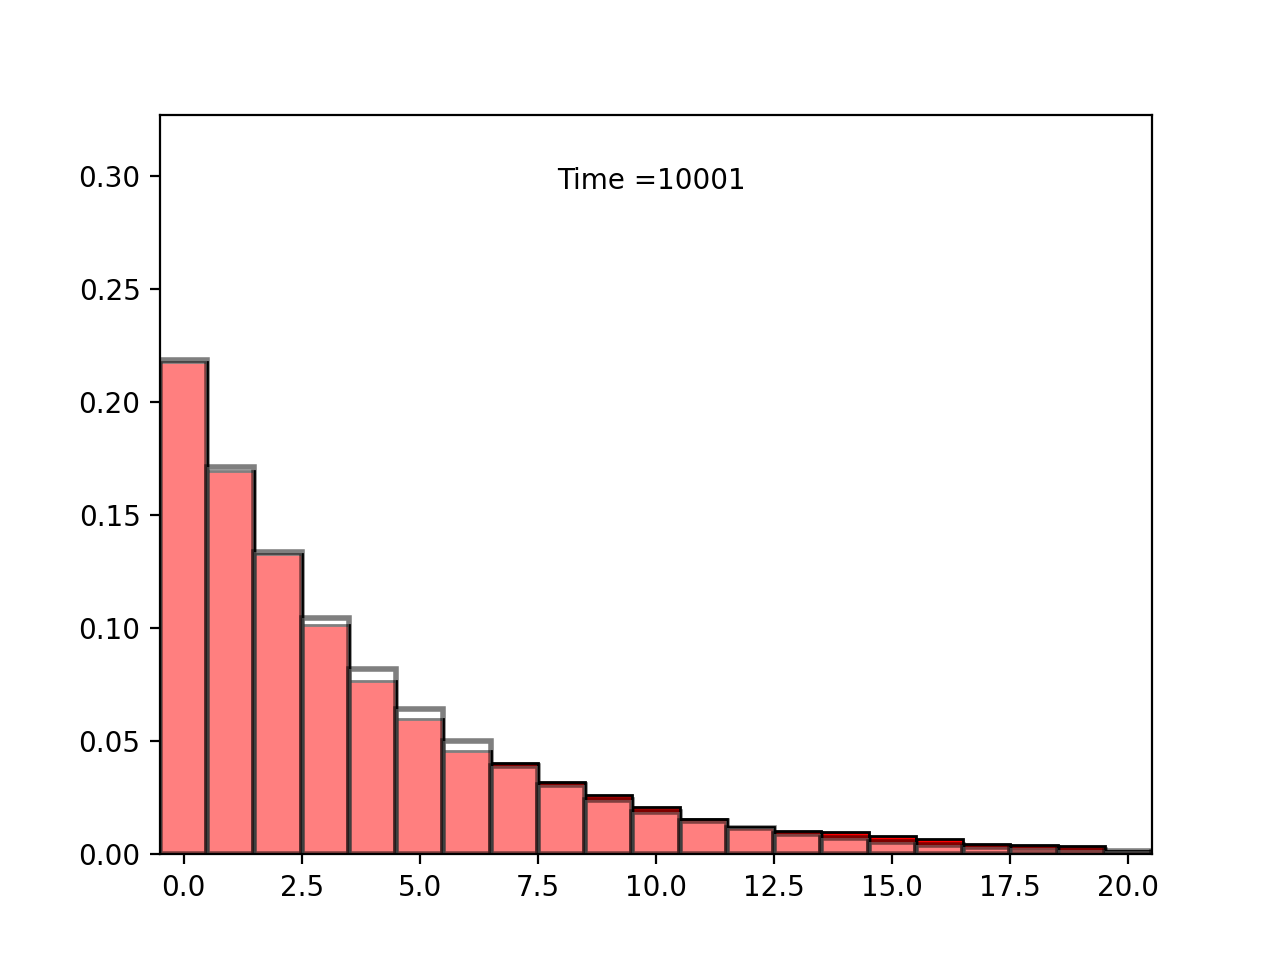

In [48]:
Qplot(qdata, pi2)

In [49]:
simulated_data = Queue(P, 20, 10000)

<IPython.core.display.Javascript object>


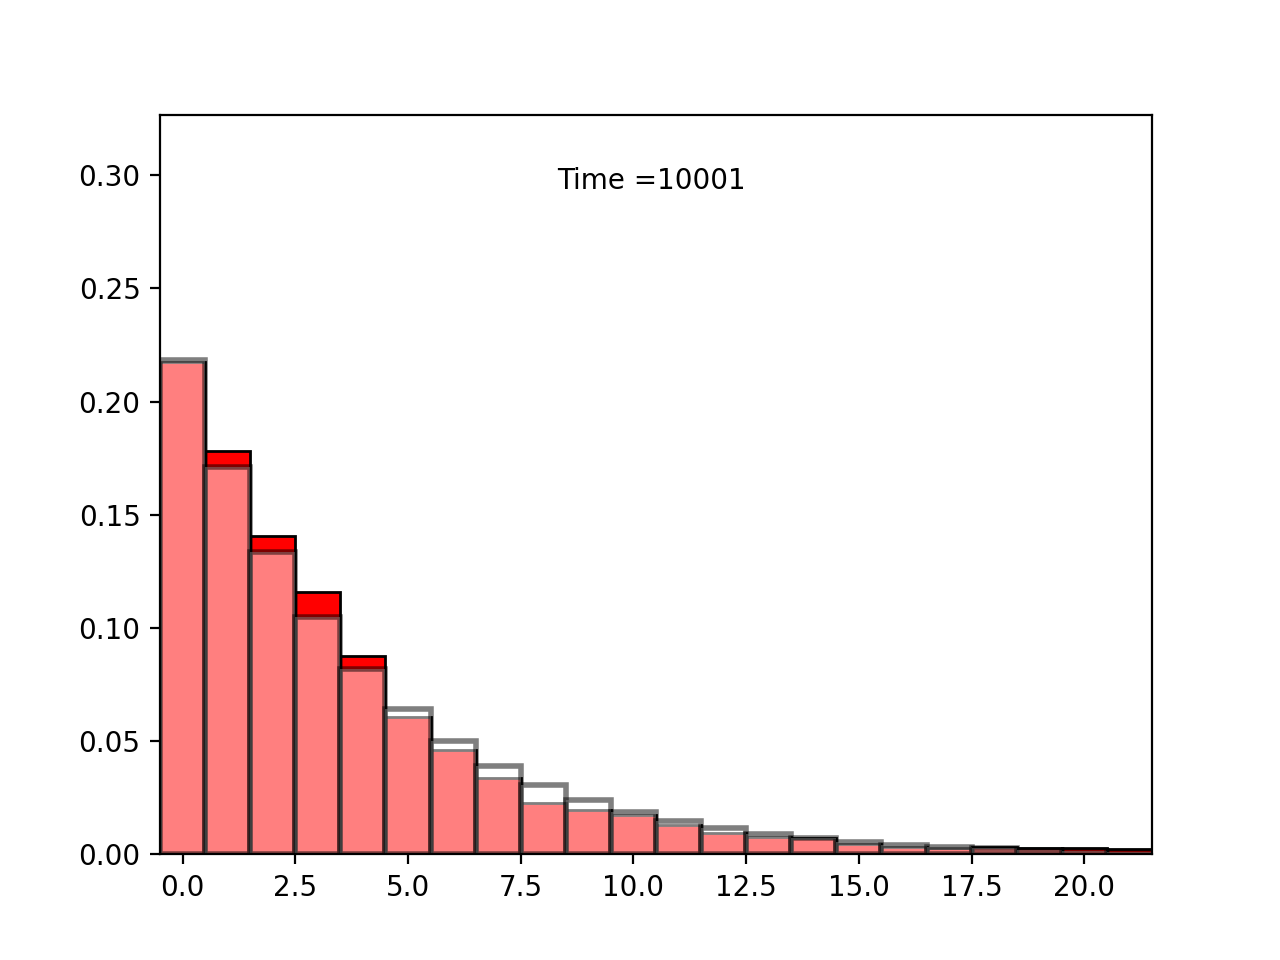

In [50]:
Qplot(simulated_data, pi2)

We can see the simulated frequencies for this system are very close to what we expect from the equilibrium probabilities. The queue is most often found empty. We see higher than expected frequencies of queue size from 7.5 to 12.5 this may be because the queue started at size 20 and if we simulated over more time intervals the frequency graph would math the equilibrium probabilities even better.

## Q.4 (*)
### Telephone Exchange Queue.
A telephone exchange consists of $N$
operators on $N$ lines. Assume that the calling and servicing patterns are
Poisson with parameters $\alpha _{k}=\alpha ,\ \beta _{k}=k\beta $
respectively for queue size of $0\leq k\leq N$ and for some $\alpha, \beta >0$.
The equilibrium distribution for the queue is: 
$$
\pi _{k}=\frac{\rho ^{k}}{k!}\left(1+\rho +\frac{\rho ^{2}}{2!}+...+\frac{\rho
^{N}}{N!}\right)^{-1},\ \rho =\ \frac{\alpha }{\beta } 
$$
Of particular interest, in this model, is the frequency with which the
exchange becomes saturated over a long period of time i.e. $\pi_N.$ This
should be a small number for an efficient exchange since it provides a
measurement of the number of calls lost to the system.

   1. A telephone exchange has 5 operators who can handle 40 calls an hour each on average. If calls arrive at the exchange on average every 40 secs, show that there is approximately a 5.5\% chance that the exchange will become saturated after a long time.

   2. Simulate this system over 3 hours with 10 sec time intervals. For what proportion of your simulated events do you find all operators are busy?
   
   3. Compare the results of your simulation to the equilibirum probabilities $\pi_{k}$.

### Hints
Calculate $\alpha,\beta$ based on the information given for the 5 operator exchange. Be consistent with use of time units. In part (2) choose 10 secs as the time interval size and construct a transition matrix $P$ before simulating. 



Calculate $\alpha,\beta$

In [51]:

#arrival rate is 1 caller every 40 seconds, 0.25 per 10 seconds
#service rate with 40 calls every hour per operator, 40/360 per 10 seconds
alpha = 1/4
beta = 1/9

In [52]:
def Nearneigh2 (pup, pdown, r):
    #An updated version of Nearneigh that takes into account 
    #a varying service rate
    P = np.zeros((r+1, r+1))
    P[0,0] = 1 - pup
    P[0,1] = pup
    P[r, r] = 1 - r*pdown
    P[r, r - 1] = r*pdown
    for i in range(1,r):
        P[i, i-1] = i*pdown
        P[i,i] = 1 - i*pdown - pup
        P[i, i + 1] = pup
    return (P)

In [53]:
r = 5 #there are 5 operators described in the question
P = Nearneigh2(alpha, beta, r)

In [54]:
pi4 = Equilibrium(P)
print("Equilibrium probabilities:\n", pi4)

Equilibrium probabilities:
 [0.10836466 0.24382049 0.27429805 0.20572354 0.11571949 0.05207377]


We can see from the equilibrium probabilities that there is a 5.207377% chance the exchange will be found saturated. There is approximately  a 5.5% chance that the exchange will become saturated after a long time.

In [55]:
#3 hours is 1080 time intervals of length 10 seconds
qdata4 = Queue(P, 0, 1080)

<IPython.core.display.Javascript object>


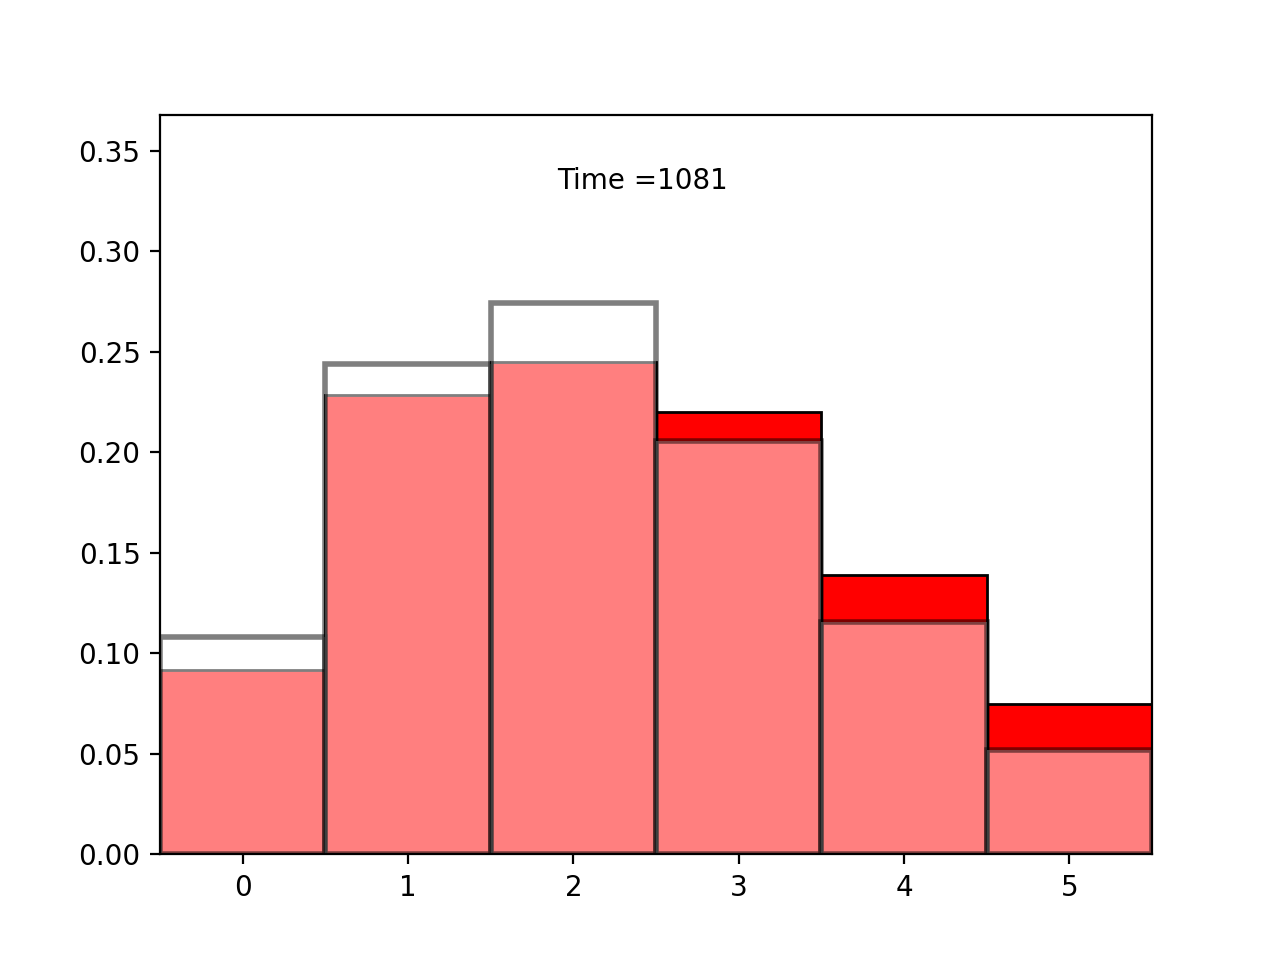

In [56]:
Qplot(qdata4, pi4)

We can see that the simulated data closely follows our expected frequencies. 

The queue in this simulated data is empty or has 1 operator busy more often than expected, and therefore is also found less often with 2, 3 or 4 operators busy. We can see that the telephone exchange was found saturated approximately 5% of the time.